# 03 — Descriptive and Diagnostic Analytics

**Project:** Explainable Scenario-Based Simulation of Aircraft Damage Consequences Among Reported Wildlife Strikes Using FAA Data

## Purpose and proposal alignment

This notebook uses the canonical analytical dataset produced by Notebook 02:

`data/processed/faa_strikes_analytical.csv`

It addresses the Week 3 activities defined in the approved project plan:

- descriptive analysis;
- statistical testing;
- effect-size estimation and interpretation;
- data-quality diagnostics to support subsequent modelling.

The analysis directly addresses:

> **RQ1:** Which aircraft, wildlife, flight, temporal, and geographic factors are associated with aircraft damage among reported wildlife strikes?

All findings apply only to reported wildlife-strike records. Record counts must not be interpreted as ordinary-flight strike probabilities, and observed associations do not establish causal relationships. Post-event consequence variables are described separately and are excluded from the predictors used for the primary aircraft-damage outcome.

In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, mannwhitneyu

from IPython.display import display

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

SEED = 42
np.random.seed(SEED)

# Locate the repository root without using machine-specific paths.
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data").exists() or (candidate / "docs").exists():
        ROOT = candidate
        break

DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
DOCS_DIR = ROOT / "docs"
PREP_OUTPUT_DIR = ROOT / "outputs" / "02_data_preparation"

INPUT_FILE = PROCESSED_DIR / "faa_strikes_analytical.csv"
FEATURE_LIST_FILE = DOCS_DIR / "feature_lists.json"
FEATURE_ELIGIBILITY_FILE = DOCS_DIR / "feature_eligibility.csv"
VALIDATION_METADATA_FILE = PREP_OUTPUT_DIR / "validation_metadata.json"

OUTPUT_DIR = ROOT / "outputs" / "03_descriptive_and_diagnostic"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
STAT_DIR = OUTPUT_DIR / "statistical_tests"

for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, STAT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Canonical input:", INPUT_FILE)
print("Output folder:", OUTPUT_DIR)


Repository root: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\faa-wildlife-strike-damage-analysis
Canonical input: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_analytical.csv
Output folder: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\faa-wildlife-strike-damage-analysis\outputs\03_descriptive_and_diagnostic


## 1. Load and validate the Notebook 02 hand-off

Notebook 03 uses the canonical analytical dataset produced by Notebook 02 and does not create a second independently cleaned version. The complete analytical export is required because this notebook describes post-event consequences that were intentionally excluded from the restricted dataset prepared for binary damage modelling.

In [2]:

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Canonical Notebook 02 output not found: {INPUT_FILE.resolve()}\n"
        "Run Notebook 02 from a fresh kernel before running this notebook."
    )

df = pd.read_csv(INPUT_FILE, low_memory=False)

required_fields = {
    "INDEX_NR",
    "INCIDENT_YEAR",
    "INCIDENT_MONTH",
    "INDICATED_DAMAGE",
    "SEASON",
    "WILDLIFE_TYPE",
    "SIZE",
    "NUM_STRUCK",
    "AC_CLASS",
    "AC_MASS_GROUP",
    "TYPE_ENG",
    "NUM_ENGS",
    "WARNED",
    "TEMPORAL_SPLIT",
}

missing_required = sorted(required_fields - set(df.columns))
if missing_required:
    raise KeyError(
        "Notebook 02 analytical output is missing required fields: "
        + ", ".join(missing_required)
    )

# Load preparation metadata when available.
feature_lists = {}
if FEATURE_LIST_FILE.exists():
    with open(FEATURE_LIST_FILE, "r", encoding="utf-8") as f:
        feature_lists = json.load(f)

validation_metadata = {}
if VALIDATION_METADATA_FILE.exists():
    with open(VALIDATION_METADATA_FILE, "r", encoding="utf-8") as f:
        validation_metadata = json.load(f)

feature_eligibility = (
    pd.read_csv(FEATURE_ELIGIBILITY_FILE)
    if FEATURE_ELIGIBILITY_FILE.exists()
    else pd.DataFrame()
)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print("Observed years:", int(df["INCIDENT_YEAR"].min()), "to", int(df["INCIDENT_YEAR"].max()))
print("Feature-list metadata loaded:", bool(feature_lists))
print("Validation metadata loaded:", bool(validation_metadata))
display(df.head())


Loaded: 319,107 rows × 147 columns
Observed years: 1990 to 2024
Feature-list metadata loaded: True
Validation metadata loaded: True


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,ENROUTE_STATE,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,INCIDENT_LATITUDE,INCIDENT_LONGITUDE,SKY,PRECIPITATION,AOS,COST_REPAIRS,COST_OTHER,COST_REPAIRS_INFL_ADJ,COST_OTHER_INFL_ADJ,INGESTED_OTHER,INDICATED_DAMAGE,DAMAGE_LEVEL,STR_RAD,DAM_RAD,STR_WINDSHLD,DAM_WINDSHLD,STR_NOSE,DAM_NOSE,STR_ENG1,DAM_ENG1,ING_ENG1,STR_ENG2,DAM_ENG2,ING_ENG2,STR_ENG3,DAM_ENG3,ING_ENG3,STR_ENG4,DAM_ENG4,ING_ENG4,STR_PROP,DAM_PROP,STR_WING_ROT,DAM_WING_ROT,STR_FUSE,DAM_FUSE,STR_LG,DAM_LG,STR_TAIL,DAM_TAIL,STR_LGHTS,DAM_LGHTS,STR_OTHER,DAM_OTHER,OTHER_SPECIFY,EFFECT,EFFECT_OTHER,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,NR_INJURIES,NR_FATALITIES,COMMENTS,IMAGE,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER,SPECIES_RAW,SPECIES_ID_RAW,SIZE_RAW,NUM_SEEN_RAW,NUM_STRUCK_RAW,PHASE_OF_FLIGHT_RAW,TIME_OF_DAY_RAW,WARNED_RAW,SKY_RAW,PRECIPITATION_RAW,AC_CLASS_RAW,DAMAGE_LEVEL_RAW,NUM_SEEN_ORDER,NUM_STRUCK_ORDER,TARGET_CONFLICT_FLAG,SEVERITY_ELIGIBLE_FLAG,WILDLIFE_TYPE,HEIGHT_INVALID_NEGATIVE_FLAG,HEIGHT_EXTREME_REVIEW_FLAG,SPEED_INVALID_NEGATIVE_FLAG,SPEED_EXTREME_REVIEW_FLAG,DISTANCE_INVALID_NEGATIVE_FLAG,DISTANCE_EXTREME_REVIEW_FLAG,NUM_ENGS_INVALID_NEGATIVE_FLAG,NUM_ENGS_EXTREME_REVIEW_FLAG,AC_MASS_INVALID_NEGATIVE_FLAG,AC_MASS_EXTREME_REVIEW_FLAG,NR_INJURIES_INVALID_NEGATIVE_FLAG,NR_INJURIES_EXTREME_REVIEW_FLAG,NR_FATALITIES_INVALID_NEGATIVE_FLAG,NR_FATALITIES_EXTREME_REVIEW_FLAG,GROUND_PHASE_HEIGHT_CONFLICT_FLAG,SEASON,MONTH_SIN,MONTH_COS,AC_MASS_GROUP,HEIGHT_MISSING_FLAG,SPEED_MISSING_FLAG,TIME_OF_DAY_MISSING_FLAG,PHASE_OF_FLIGHT_MISSING_FLAG,SIZE_MISSING_FLAG,SKY_MISSING_FLAG,PRECIPITATION_MISSING_FLAG,TEMPORAL_SPLIT
0,608407,15/10/1990 00:00:00,10,1990,10:07,Night,KTRI,TRI-CITIES REGIONAL TN/VA ARPT,NaN,NaN,23,TN,ASO,NaN,NaN,NAE,NASHVILLE EAGLE,NaN,NaN,MERLIN IV,915,06,19.0,4.0,A,2.0,C,2.0,4.0,4.0,NaN,NaN,Approach,1500.0,160.0,NaN,NaN,NaN,No Cloud,Not reported,NaN,NaN,NaN,NaN,NaN,0,0,N,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,UNKBM,Unknown bird - medium,BIRDS BELIEVED TO BE GEESE. 3 NW OF AIRPORT O...,0,0,Unknown,2–10,1,Medium,0.0,0.0,/Legacy Record 100166/,0,REDACTED,REDACTED,FAA Form 5200-7,NaN,4/12/1998 00:00:00,0,Unknown bird - medium,UNKBM,Medium,2-10,1,Approach,Night,Unknown,No Cloud,NaN,A,N,2.0,1.0,0,0,Bird,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Autumn,-0.866025,5.000000e-01,Light,0,0,0,0,0,0,1,train_1990_2018
1,608408,7/4/1991 00:00:00,4,1991,NaN,Day,KMDT,HARRISBURG INTL,NaN,NaN,31,PA,AEA,NaN,NaN,AAL,AMERICAN AIRLINES,N842AA,NaN,B-727-200,148,11,34.0,10.0,A,4.0,D,3.0,5.0,6.0,5.0,NaN,Landing Roll,0.0,120.0,0.0,NaN,NaN,No Cloud,Not reported,NaN,NaN,NaN,NaN,NaN,0,0,N,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NE1,Gulls,"# BIRDS STRUCK NOT REPTD, ASSUME 1.",0,0,No,More than 100,1,Medium,0.0,0.0,/Legacy Record 100167/,0,REDACTED,REDACTED,FAA Form 5200-7,Pilot,5/12/1997 00:00:00,0,Gulls,NE1,Medium,More than 100,1,Landing Roll,Day,No,No Cloud,NaN,A,N,4.0,1.0,0,0,Bird,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Spring,0.866025,-5.000000e-01,Heavy,0,0,0,0,0,0,1,train_1990_2018
2,608409,27/10/1991 00:00:00,10,1991,NaN,Day,KLAN,CAPITAL REGION INTL ARPT,NaN,NaN,NaN,MI,AGL,NaN,NaN,SYM,SIMMONS AVIATN,NaN,NaN,SHORTS 360,804,08,31.0,4.0,A,3.0,C,2.0,4.0,4.0,NaN,NaN,Landing Roll,0.0,NaN,0.0,NaN,NaN,Overcast,Not reported,NaN,NaN,NaN,NaN,NaN,0,0,N,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NE1,Gulls,"HIT A FLOCK OF GULLS, # NOT REPTD, ASSUME 2-10...",0,0,Yes,2–10,2–10,Medium,0.0,0.0,/Legacy Record 100168/,0,REDACTED,REDACTED,FAA Form 5200-7,Tower,23/7/1997 00:00:00,0,Gulls,NE1,Medium,2-10,2-10,Landing Roll,Day,Yes,Overcast,NaN,A,N

In [3]:

# Validate the locked population and primary target.
df["INCIDENT_YEAR"] = pd.to_numeric(df["INCIDENT_YEAR"], errors="coerce").astype("Int64")
df["INCIDENT_MONTH"] = pd.to_numeric(df["INCIDENT_MONTH"], errors="coerce").astype("Int64")
df["INDICATED_DAMAGE"] = pd.to_numeric(
    df["INDICATED_DAMAGE"], errors="coerce"
).astype("Int64")

validation_checks = pd.DataFrame([
    {
        "check": "Rows",
        "result": len(df),
        "status": "information",
    },
    {
        "check": "Columns",
        "result": df.shape[1],
        "status": "information",
    },
    {
        "check": "Minimum year",
        "result": df["INCIDENT_YEAR"].min(),
        "status": "pass" if df["INCIDENT_YEAR"].min() == 1990 else "review",
    },
    {
        "check": "Maximum year",
        "result": df["INCIDENT_YEAR"].max(),
        "status": "pass" if df["INCIDENT_YEAR"].max() == 2024 else "review",
    },
    {
        "check": "Rows outside 1990–2024",
        "result": int((~df["INCIDENT_YEAR"].between(1990, 2024)).sum()),
        "status": "pass" if (~df["INCIDENT_YEAR"].between(1990, 2024)).sum() == 0 else "fail",
    },
    {
        "check": "Missing primary target",
        "result": int(df["INDICATED_DAMAGE"].isna().sum()),
        "status": "pass" if df["INDICATED_DAMAGE"].isna().sum() == 0 else "fail",
    },
    {
        "check": "Unexpected primary-target values",
        "result": sorted(
            set(df["INDICATED_DAMAGE"].dropna().astype(int).unique()) - {0, 1}
        ),
        "status": "pass"
        if set(df["INDICATED_DAMAGE"].dropna().astype(int).unique()).issubset({0, 1})
        else "fail",
    },
    {
        "check": "Exact duplicate rows",
        "result": int(df.duplicated().sum()),
        "status": "pass" if df.duplicated().sum() == 0 else "review",
    },
    {
        "check": "Repeated INDEX_NR values",
        "result": int(df["INDEX_NR"].duplicated(keep=False).sum()),
        "status": "pass" if df["INDEX_NR"].duplicated(keep=False).sum() == 0 else "review",
    },
])

display(validation_checks)
validation_checks.to_csv(TABLE_DIR / "00_dataset_validation.csv", index=False)

failed_checks = validation_checks.loc[
    validation_checks["status"].eq("fail"), "check"
].tolist()
if failed_checks:
    raise AssertionError(
        "Canonical-data validation failed: " + ", ".join(failed_checks)
    )


,check,result,status
0,Rows,319107,information
1,Columns,147,information
2,Minimum year,1990,pass
3,Maximum year,2024,pass
4,Rows outside 1990–2024,0,pass
5,Missing primary target,0,pass
6,Unexpected primary-target values,[],pass
7,Exact duplicate rows,0,pass
8,Repeated INDEX_NR values,0,pass


### Data hand-off and validation results

The notebook successfully loaded the canonical analytical dataset produced by Notebook 02. The dataset contains 319,107 reported wildlife-strike records and 147 variables covering the analytical period from 1990 to 2024. The feature-list and validation metadata were also loaded successfully, confirming consistency with the feature definitions, leakage controls, and validation design established during data preparation.

All validation checks passed. There were no records outside the selected analytical period, no exact duplicate rows, and no repeated `INDEX_NR` values. The primary target, `INDICATED_DAMAGE`, was complete for all 319,107 records and contained only the valid binary values 0 and 1. Although pandas displayed an `<NA>` category because the variable uses the nullable `Int64` data type, the number of records in this category was zero. The dataset is therefore suitable for descriptive, statistical, and subsequent predictive analyses.

## 2. Local descriptive-only derivations

The canonical Notebook 02 dataset is not modified or overwritten. `DAY_OF_WEEK` is derived locally from `INCIDENT_DATE` only for the descriptive and statistical analyses in this notebook. Notebook 02 remains the single source of truth for all cleaned and engineered variables used in subsequent modelling.

In [4]:

analysis_df = df.copy()

if "INCIDENT_DATE" in analysis_df.columns:
    try:
        incident_date = pd.to_datetime(
            analysis_df["INCIDENT_DATE"], errors="coerce", format="mixed"
        )
    except (TypeError, ValueError):
        incident_date = pd.to_datetime(
            analysis_df["INCIDENT_DATE"], errors="coerce"
        )
    analysis_df["DAY_OF_WEEK"] = incident_date.dt.day_name()
else:
    analysis_df["DAY_OF_WEEK"] = pd.NA

# Use the canonical state field from Notebook 02.
if "STATE" not in analysis_df.columns and "INCIDENT_STATE" in analysis_df.columns:
    warnings.warn(
        "Legacy INCIDENT_STATE found. A local STATE alias was created, but "
        "Notebook 02 should normally export STATE."
    )
    analysis_df["STATE"] = analysis_df["INCIDENT_STATE"]

# Do not change the canonical source file.
print("Local analysis copy created:", analysis_df.shape)


Local analysis copy created: (319107, 148)


### Local analytical derivation

A local analysis copy was created with the same 319,107 records as the canonical dataset. The number of variables increased from 147 to 148 because `DAY_OF_WEEK` was derived from `INCIDENT_DATE` for temporal descriptive analysis. This additional variable exists only in the local analytical copy and does not modify or overwrite the canonical dataset produced by Notebook 02.


## 3. Reusable output and summary functions

Reusable helper functions are defined to produce consistent tables, figures, and summary outputs throughout the notebook. All final tables are exported as CSV files, all final figures are saved as PNG files at 300 dpi, and a complete output manifest is generated at the end of the notebook.

In [5]:

output_manifest = []

def save_table(table, filename, folder=TABLE_DIR):
    path = folder / filename
    table.to_csv(path, index=False)
    output_manifest.append({
        "artifact_type": "table",
        "filename": filename,
        "relative_path": str(path.relative_to(ROOT)),
        "rows": len(table),
        "columns": table.shape[1],
    })
    return path

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    output_manifest.append({
        "artifact_type": "figure",
        "filename": filename,
        "relative_path": str(path.relative_to(ROOT)),
        "rows": pd.NA,
        "columns": pd.NA,
    })
    return path

def wilson_interval(successes, totals, z=1.96):
    successes = np.asarray(successes, dtype=float)
    totals = np.asarray(totals, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        p = successes / totals
        denominator = 1 + (z ** 2 / totals)

        centre = (
            p + z ** 2 / (2 * totals)
        ) / denominator

        margin = (
            z
            * np.sqrt(
                (p * (1 - p) / totals)
                + (z ** 2 / (4 * totals ** 2))
            )
            / denominator
        )

    lower = np.clip(
        (centre - margin) * 100,
        0,
        100
    )

    upper = np.clip(
        (centre + margin) * 100,
        0,
        100
    )

    return lower, upper

def outcome_by_category(data, group_columns, sort_by="Reported_Strikes"):
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    summary = (
        data.groupby(group_columns, dropna=False)
        .agg(
            Reported_Strikes=("INDEX_NR", "size"),
            Damage_Records=("INDICATED_DAMAGE", "sum"),
        )
        .reset_index()
    )
    summary["No_Damage_Records"] = (
        summary["Reported_Strikes"] - summary["Damage_Records"]
    )
    summary["Damage_Rate_Pct"] = (
        summary["Damage_Records"] / summary["Reported_Strikes"] * 100
    )
    lower, upper = wilson_interval(
        summary["Damage_Records"], summary["Reported_Strikes"]
    )
    summary["Damage_Rate_CI95_Lower"] = lower
    summary["Damage_Rate_CI95_Upper"] = upper
    return summary.sort_values(sort_by, ascending=False).reset_index(drop=True)

def display_label_table(summary, category_columns):
    labelled = summary.copy()
    if isinstance(category_columns, str):
        category_columns = [category_columns]
    labelled["Category_Label"] = (
        labelled[category_columns]
        .astype("string")
        .fillna("Missing")
        .agg(" | ".join, axis=1)
    )
    return labelled

def plot_counts(summary, category_columns, title, filename, top_n=None):
    plot_data = display_label_table(summary, category_columns)
    if top_n is not None:
        plot_data = plot_data.nlargest(top_n, "Reported_Strikes")
    plot_data = plot_data.sort_values("Reported_Strikes", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_data))))
    ax.barh(plot_data["Category_Label"], plot_data["Reported_Strikes"])
    ax.set_title(title)
    ax.set_xlabel("Number of reported strikes")
    ax.set_ylabel("")
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()

def plot_damage_rates(
    summary,
    category_columns,
    title,
    filename,
    top_n=None,
    minimum_records=1,
):
    plot_data = summary.loc[
        summary["Reported_Strikes"] >= minimum_records
    ].copy()
    if top_n is not None:
        plot_data = plot_data.nlargest(top_n, "Reported_Strikes")
    plot_data = display_label_table(plot_data, category_columns)
    plot_data = plot_data.sort_values("Damage_Rate_Pct", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_data))))
    ax.barh(plot_data["Category_Label"], plot_data["Damage_Rate_Pct"])
    ax.set_title(title)
    ax.set_xlabel("Reported aircraft-damage rate (%)")
    ax.set_ylabel("")
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


In [6]:
print(analysis_df["INDICATED_DAMAGE"].dtype)
print(analysis_df["INDICATED_DAMAGE"].value_counts(dropna=False))
print(analysis_df["INDICATED_DAMAGE"].unique())

Int64
INDICATED_DAMAGE
0       298199
1        20908
<NA>         0
Name: count, dtype: Int64
<IntegerArray>
[0, 1]
Length: 2, dtype: Int64


## 4. Dataset overview and target distribution

This section summarizes the analytical dataset and examines the distribution of the primary binary target, `INDICATED_DAMAGE`. It confirms the number of records, analytical period, target completeness, and the level of class imbalance before the descriptive and statistical analyses.

,Metric,Value
0,Reported strike records,319107.000000
1,First analytical year,1990.000000
2,Last analytical year,2024.000000
3,Reporting years,35.000000
4,Damaging records,20908.000000
5,Non-damaging records,298199.000000
6,Overall reported damage rate (%),6.552034
7,Distinct FAA regions,11.000000
8,Distinct states,68.000000
9,Distinct airports,2708.000000


,INDICATED_DAMAGE,Records,Damage_Status,Percentage
0,0,298199,No damage reported,93.447966
1,1,20908,Damage reported,6.552034


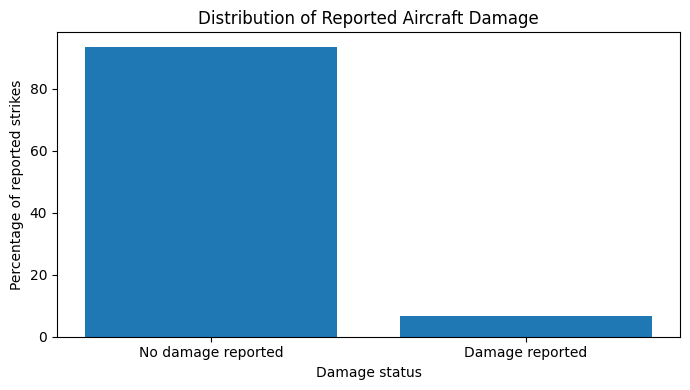

In [7]:
overall_summary = pd.DataFrame({
    "Metric": [
        "Reported strike records",
        "First analytical year",
        "Last analytical year",
        "Reporting years",
        "Damaging records",
        "Non-damaging records",
        "Overall reported damage rate (%)",
        "Distinct FAA regions",
        "Distinct states",
        "Distinct airports",
        "Distinct exact species labels",
        "Distinct broad wildlife types",
        "Target conflict flags",
    ],
    "Value": [
        len(analysis_df),
        analysis_df["INCIDENT_YEAR"].min(),
        analysis_df["INCIDENT_YEAR"].max(),
        analysis_df["INCIDENT_YEAR"].nunique(),
        int(analysis_df["INDICATED_DAMAGE"].sum()),
        int((analysis_df["INDICATED_DAMAGE"] == 0).sum()),
        analysis_df["INDICATED_DAMAGE"].mean() * 100,
        (
            analysis_df["FAAREGION"].nunique(dropna=False)
            if "FAAREGION" in analysis_df.columns
            else pd.NA
        ),
        (
            analysis_df["STATE"].nunique(dropna=False)
            if "STATE" in analysis_df.columns
            else pd.NA
        ),
        (
            analysis_df["AIRPORT_ID"].nunique(dropna=False)
            if "AIRPORT_ID" in analysis_df.columns
            else pd.NA
        ),
        (
            analysis_df["SPECIES"].nunique(dropna=False)
            if "SPECIES" in analysis_df.columns
            else pd.NA
        ),
        (
            analysis_df["WILDLIFE_TYPE"].nunique(dropna=False)
            if "WILDLIFE_TYPE" in analysis_df.columns
            else pd.NA
        ),
        (
            int(
                pd.to_numeric(
                    analysis_df["TARGET_CONFLICT_FLAG"],
                    errors="coerce"
                )
                .fillna(0)
                .sum()
            )
            if "TARGET_CONFLICT_FLAG" in analysis_df.columns
            else pd.NA
        ),
    ],
})

# Create damage distribution.
# dropna=True prevents the empty <NA> category from appearing.
damage_distribution = (
    analysis_df["INDICATED_DAMAGE"]
    .value_counts(dropna=True)
    .sort_index()
    .rename_axis("INDICATED_DAMAGE")
    .reset_index(name="Records")
)

damage_distribution["Damage_Status"] = (
    damage_distribution["INDICATED_DAMAGE"]
    .astype(int)
    .map({
        0: "No damage reported",
        1: "Damage reported",
    })
)

damage_distribution["Percentage"] = (
    damage_distribution["Records"].astype(float)
    / len(analysis_df)
    * 100
)

# Export tables.
save_table(
    overall_summary,
    "01_overall_summary.csv"
)

save_table(
    damage_distribution,
    "02_damage_distribution.csv"
)

# Display tables.
display(overall_summary)
display(damage_distribution)

# Create and export figure.
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    damage_distribution["Damage_Status"].astype(str),
    damage_distribution["Percentage"].astype(float)
)

ax.set_title("Distribution of Reported Aircraft Damage")
ax.set_xlabel("Damage status")
ax.set_ylabel("Percentage of reported strikes")

plt.tight_layout()

save_figure(
    fig,
    "01_damage_distribution.png"
)

plt.show()

### Dataset overview and damage distribution

The dataset contains 319,107 reported wildlife-strike records from 1990 to 2024. Aircraft damage was reported in 20,908 records (6.55%), while 298,199 records (93.45%) reported no damage.

This class imbalance should be considered during model training and evaluation. No target conflicts were identified. The damage rate applies only to reported wildlife strikes and does not represent the probability of damage during an ordinary flight.


## 5. RQ1 descriptive association tables

Each table reports record counts, reported damage counts, damage rates, and 95% Wilson confidence intervals. Counts and rates are presented together because categories with many reported strikes do not necessarily have high damage rates, while high rates based on small record counts may be less precise.

In [8]:

# Canonical category orders from Notebook 02.
category_orders = {
    "INCIDENT_MONTH": list(range(1, 13)),
    "SEASON": ["Winter", "Spring", "Summer", "Autumn", "Unknown"],
    "DAY_OF_WEEK": [
        "Monday", "Tuesday", "Wednesday", "Thursday",
        "Friday", "Saturday", "Sunday"
    ],
    "TIME_OF_DAY": ["Dawn", "Day", "Dusk", "Night", "Unknown", "Not reported"],
    "SIZE": ["Small", "Medium", "Large", "Unknown", "Not reported"],
    "NUM_STRUCK": [
        "1", "2–10", "11–100", "More than 100", "Unknown", "Not reported"
    ],
    "AC_MASS_GROUP": ["Light", "Medium", "Heavy", "Unknown"],
    "WARNED": ["Yes", "No", "Unknown", "Not reported"],
}

analysis_specs = {
    "temporal": [
        ("INCIDENT_YEAR", "incident_year"),
        ("INCIDENT_MONTH", "incident_month"),
        ("SEASON", "season"),
        ("DAY_OF_WEEK", "day_of_week"),
        ("TIME_OF_DAY", "time_of_day"),
    ],
    "geographic": [
        ("FAAREGION", "faa_region"),
        ("STATE", "state"),
    ],
    "wildlife": [
        ("WILDLIFE_TYPE", "wildlife_type"),
        ("SIZE", "wildlife_size"),
        ("NUM_STRUCK", "number_struck"),
        ("SPECIES", "exact_species"),
    ],
    "aircraft": [
        ("AC_CLASS", "aircraft_class"),
        ("AC_MASS_GROUP", "aircraft_mass_group"),
        ("TYPE_ENG", "engine_type"),
        ("NUM_ENGS", "number_of_engines"),
    ],
    "flight": [
        ("PHASE_OF_FLIGHT", "phase_of_flight"),
        ("WARNED", "warning_status"),
    ],
    "environmental_context": [
        ("SKY", "sky_condition"),
        ("PRECIPITATION", "precipitation"),
    ],
}

summary_tables = {}

for domain, specifications in analysis_specs.items():
    for column, stem in specifications:
        if column not in analysis_df.columns:
            warnings.warn(f"Skipping unavailable field: {column}")
            continue

        summary = outcome_by_category(analysis_df, column)

        if column in category_orders:
            order_map = {
                value: position
                for position, value in enumerate(category_orders[column])
            }
            summary["_order"] = summary[column].map(order_map).fillna(999)
            summary = (
                summary.sort_values(
                    ["_order", "Reported_Strikes"],
                    ascending=[True, False]
                )
                .drop(columns="_order")
                .reset_index(drop=True)
            )

        key = f"{domain}_{stem}"
        summary_tables[key] = summary
        save_table(summary, f"{domain}_{stem}.csv")

# Airport needs both identifier and name.
if {"AIRPORT_ID", "AIRPORT"}.issubset(analysis_df.columns):
    airport_summary = outcome_by_category(
        analysis_df, ["AIRPORT_ID", "AIRPORT"]
    )
    summary_tables["geographic_airport"] = airport_summary
    save_table(airport_summary, "geographic_airport.csv")

print(f"Exported {len(summary_tables)} RQ1 descriptive tables.")


Exported 20 RQ1 descriptive tables.


In [9]:

# Display the core proposal-aligned summaries.
core_display_keys = [
    "temporal_season",
    "geographic_faa_region",
    "wildlife_wildlife_type",
    "wildlife_wildlife_size",
    "wildlife_number_struck",
    "aircraft_aircraft_class",
    "aircraft_aircraft_mass_group",
    "aircraft_engine_type",
    "flight_phase_of_flight",
    "flight_warning_status",
]

for key in core_display_keys:
    if key in summary_tables:
        print("\n", key)
        display(summary_tables[key])



 temporal_season


,SEASON,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Winter,32443,3559,28884,10.970009,10.634550,11.314710
1,Spring,68557,5247,63310,7.653485,7.456842,7.854875
2,Summer,112062,4667,107395,4.164659,4.049250,4.283210
3,Autumn,106045,7435,98610,7.011175,6.859045,7.166418



 geographic_faa_region


,FAAREGION,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,ASO,60200,3539,56661,5.878738,5.693630,6.069475
1,AEA,43555,2923,40632,6.711055,6.479863,6.949882
2,AGL,43425,2441,40984,5.621186,5.408446,5.841777
3,Not reported,41103,4295,36808,10.449359,10.157314,10.748796
4,ASW,37244,1803,35441,4.841048,4.627684,5.063727
5,AWP,34022,2203,31819,6.475222,6.218607,6.741664
6,ANM,29340,1581,27759,5.388548,5.135974,5.652803
7,ACE,12986,818,12168,6.299091,5.894019,6.730012
8,ANE,10312,632,9680,6.128782,5.681963,6.608276
9,FGN,5340,464,4876,8.689139,7.963023,9.474649



 wildlife_wildlife_type


...

,TYPE_ENG,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,D,192284,13250,179034,6.890849,6.778490,7.004931
1,Not reported,91258,312,90946,0.341888,0.306049,0.381907
2,C,15364,2246,13118,14.618589,14.068785,15.186082
3,A,15167,4153,11014,27.381816,26.677934,28.097152
4,F,4613,842,3771,18.252764,17.164613,19.393748
5,B,413,102,311,24.697337,20.783959,29.077091
6,E,5,3,2,60.0,23.071993,88.238177
7,Y,3,0,3,0.0,0.000000,56.150608



 flight_phase_of_flight


,PHASE_OF_FLIGHT,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Not reported,124521,2500,122021,2.007693,1.931254,2.087094
1,Approach,82366,7172,75194,8.707476,8.516846,8.901958
2,Landing Roll,35183,2005,33178,5.698775,5.461340,5.945883
3,Take-off Run,32638,2473,30165,7.577057,7.294923,7.869178
4,Climb,29077,4287,24790,14.743612,14.340752,15.155787
5,En Route,5871,1774,4097,30.216317,29.054946,31.403562
6,Departure,3546,116,3430,3.271292,2.734501,3.909221
7,Descent,2707,402,2305,14.850388,13.560631,16.239767
8,Local,1404,91,1313,6.481481,5.308689,7.891773
9,Arrival,927,43,884,4.638619,3.461784,6.189869



 flight_warning_status


,WARNED,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Yes,56494,4152,52342,7.349453,7.137159,7.567548
1,No,64521,7579,56942,11.746563,11.500395,11.997287
2,Unknown,198092,9177,188915,4.632696,4.541009,4.726142


### Key descriptive findings for RQ1

Damage patterns differed across temporal, geographic, wildlife, aircraft, and flight characteristics. Winter had the highest seasonal damage rate at 10.97%, while summer had the largest number of reported strikes but the lowest seasonal damage rate at 4.16%. Geographic damage rates also varied, although the high rate for records with an unreported FAA region indicates that missing geographic information must be considered.

Wildlife characteristics showed clear descriptive patterns. Large wildlife had a damage rate of 32.96%, compared with 12.59% for medium and 2.04% for small wildlife. Damage rates also increased with the reported number struck, from 5.87% for one animal to 20.38% for 11–100 animals. The estimate for more than 100 animals was high but based on only 57 records and therefore had a wide confidence interval.

Among broad wildlife groups, terrestrial mammals had the highest damage rate at 7.74%, followed by birds at 6.78%. Aircraft characteristics also differed: light aircraft had a higher damage rate than medium and heavy aircraft, while helicopters had a higher rate than airplanes. However, categories with very few records and the large “Unknown” or “Not reported” groups should not be interpreted as reliable operational comparisons.

Flight phase showed substantial variation. En-route strikes had the highest reported damage rate at 30.22%, followed by descent and climb at approximately 15%. Records in which no warning was reported had a higher damage rate than records with a warning. These results describe associations among reported strikes only; statistical tests and effect sizes are required before determining which factors have the strongest practical relationships with aircraft damage.


## 6. Final descriptive figures

This section presents the main descriptive figures used to visualize reported strike counts and damage rates. For high-cardinality variables such as airports and species, minimum record thresholds are applied only to improve the stability and readability of the figures. The complete unfiltered results remain available in the exported tables.

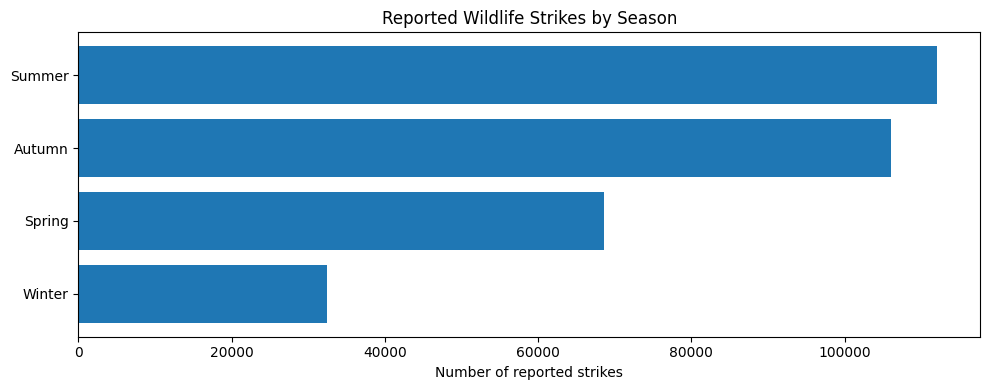

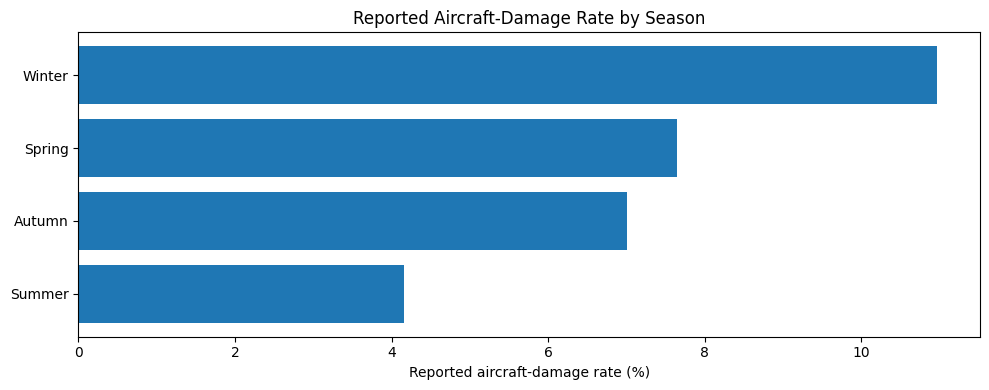

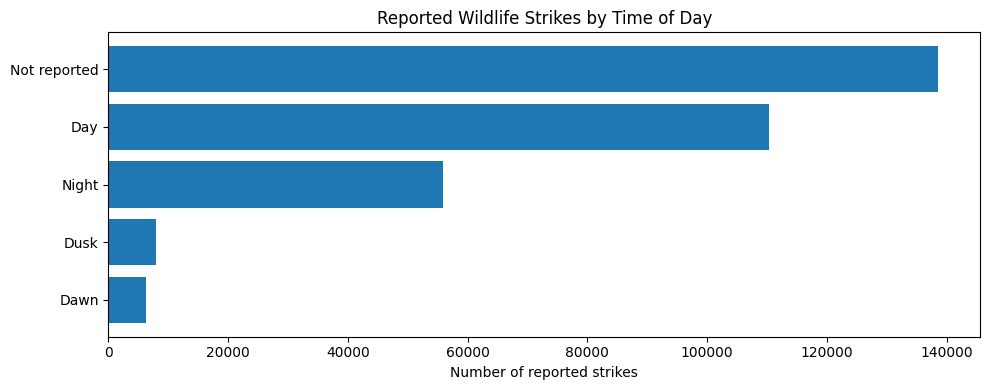

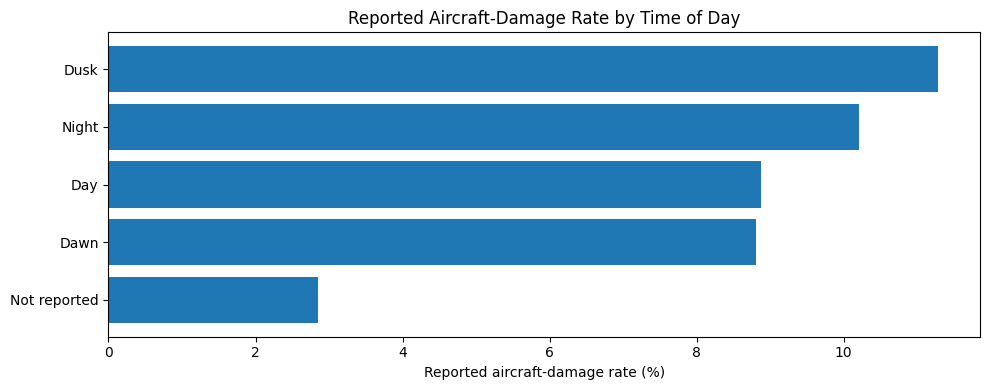

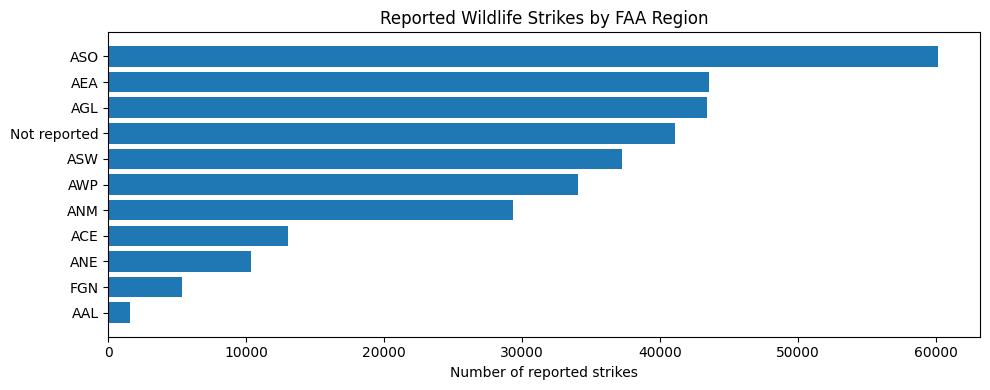

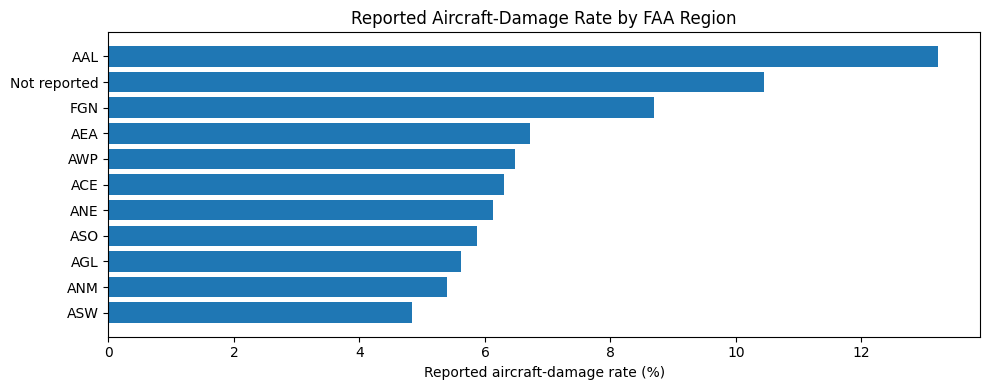

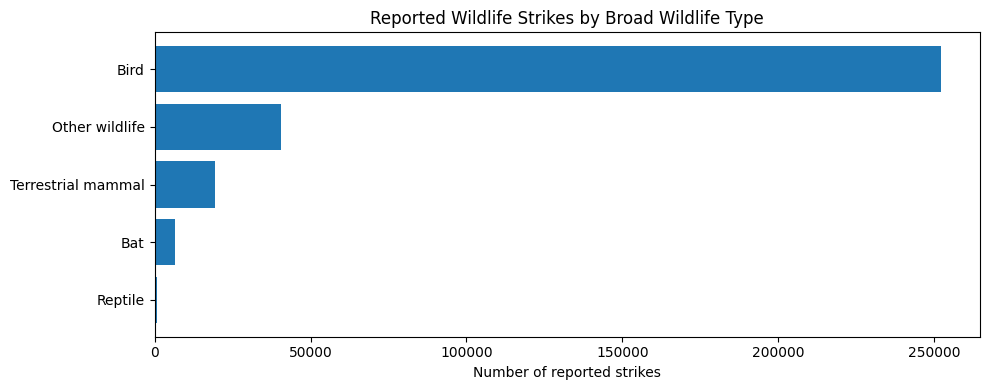

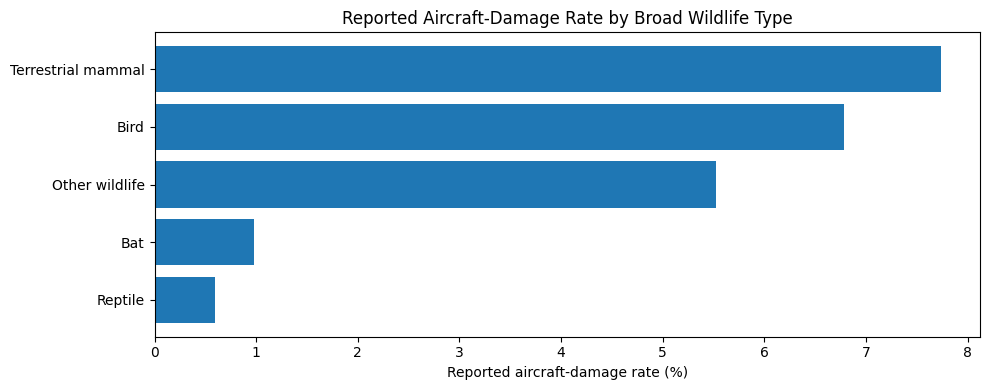

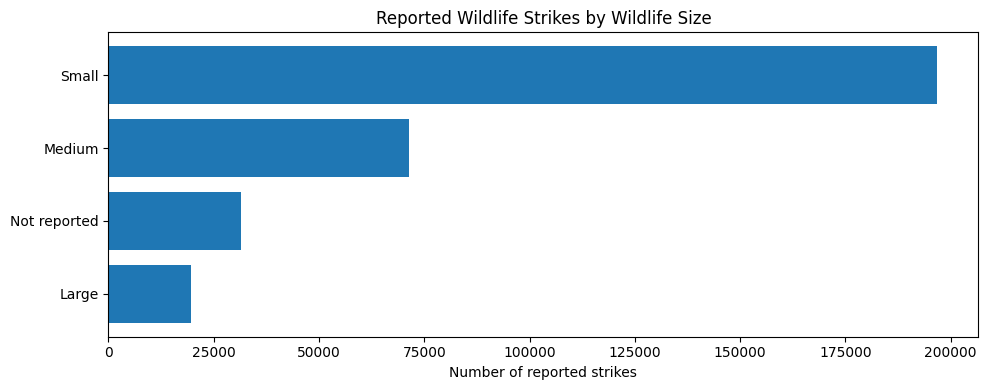

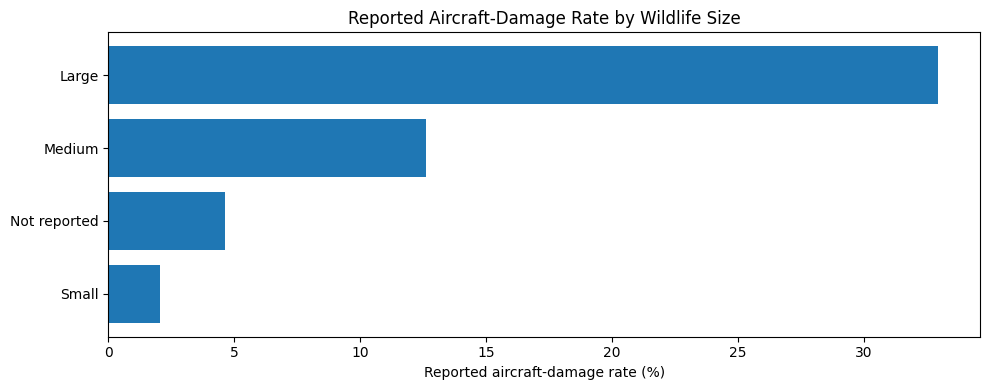

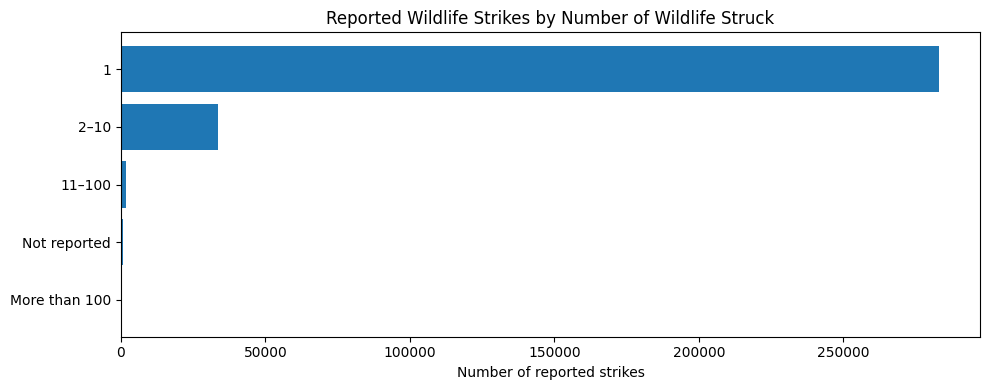

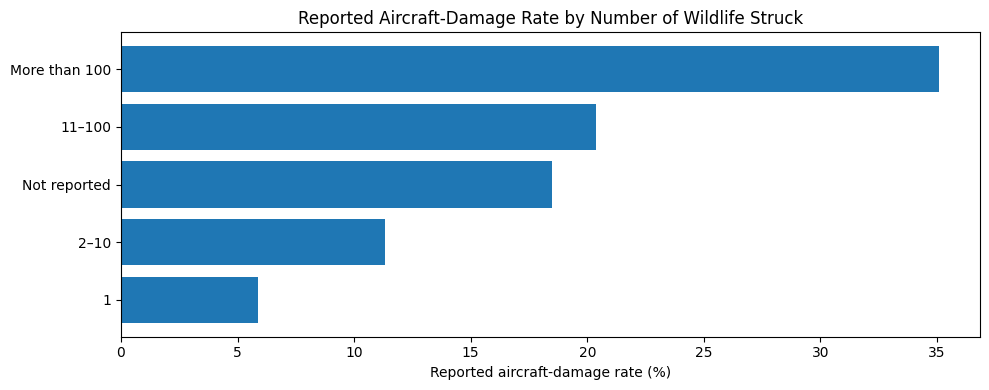

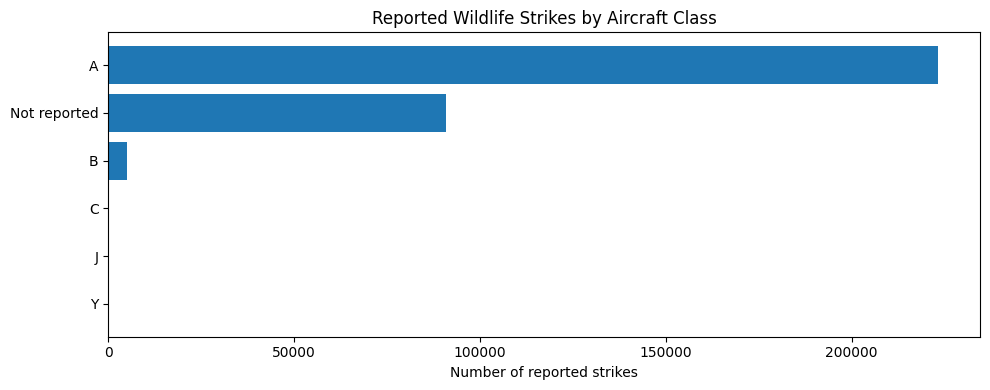

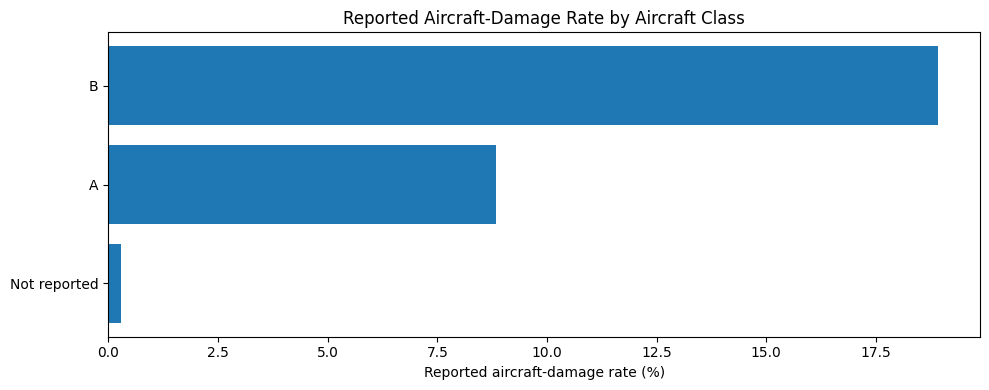

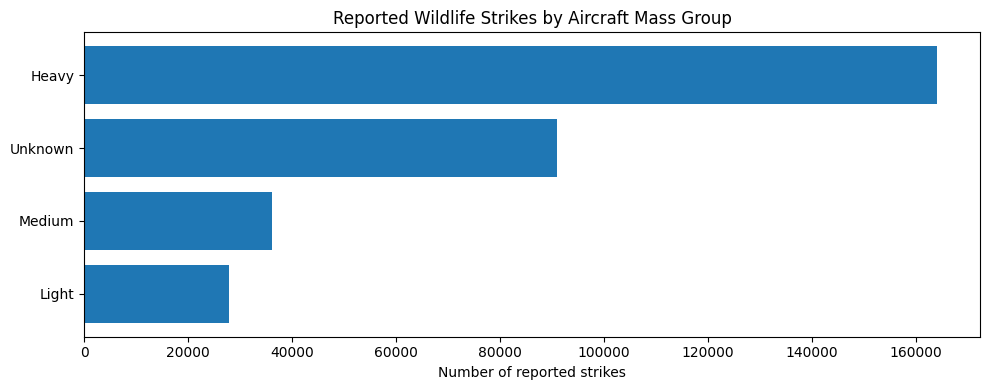

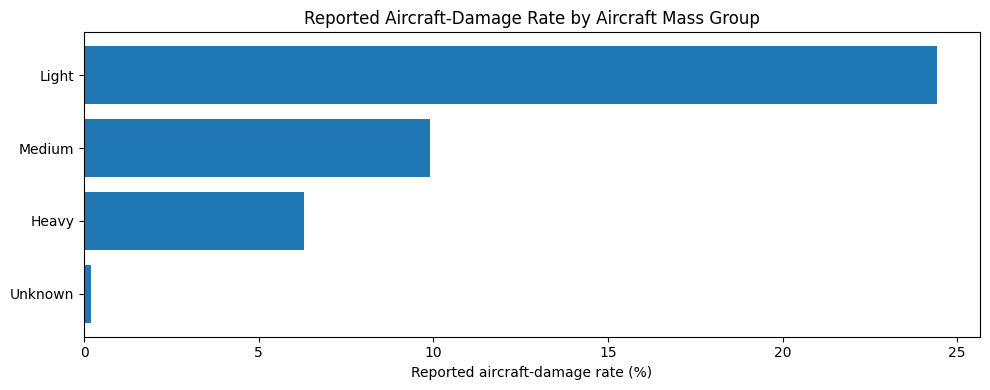

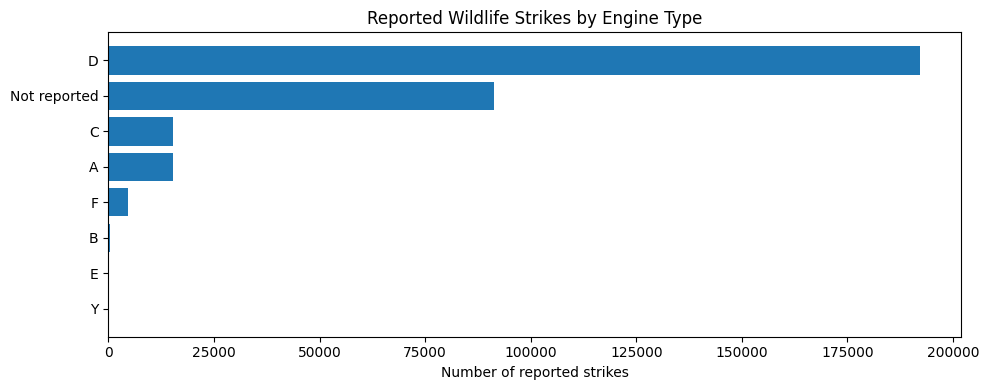

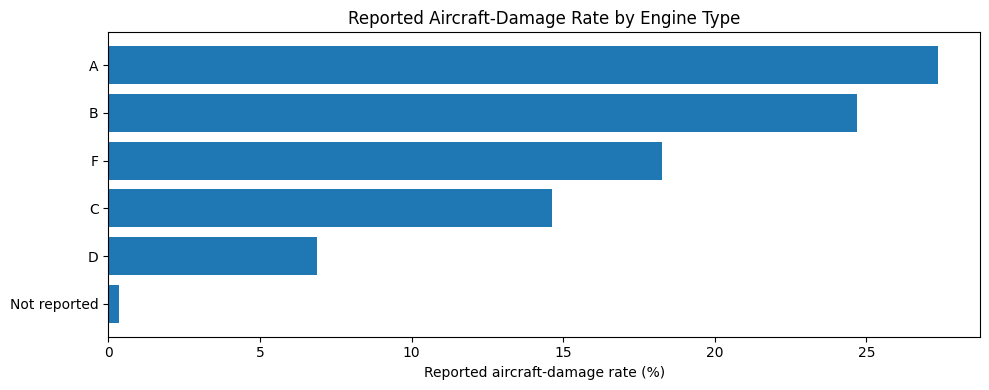

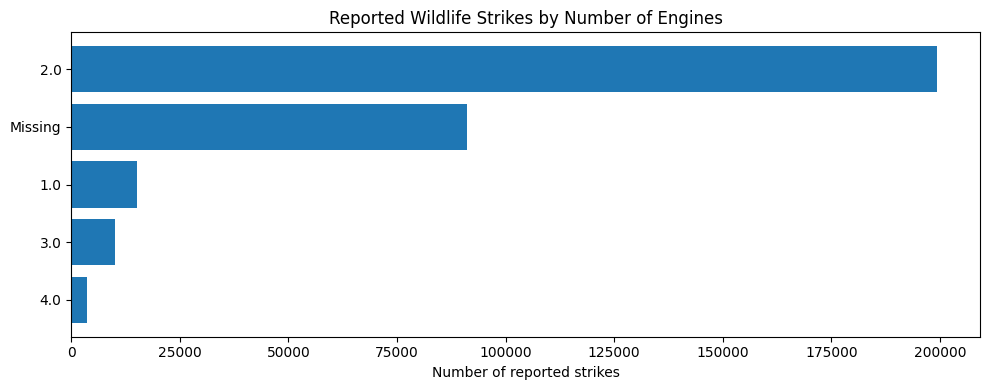

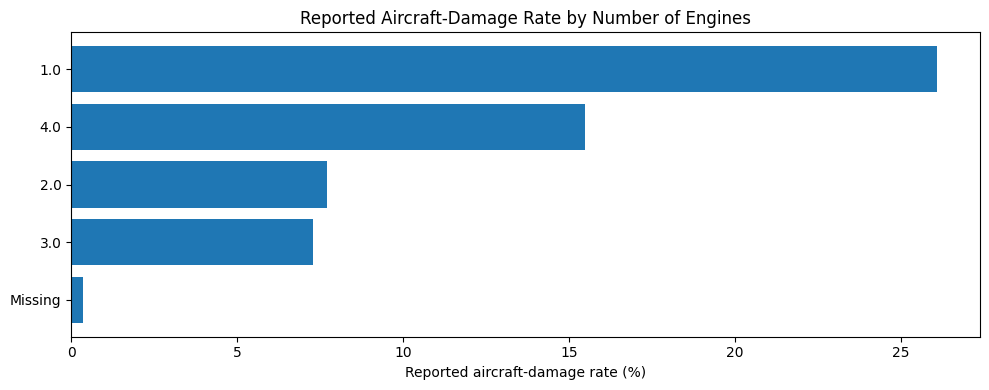

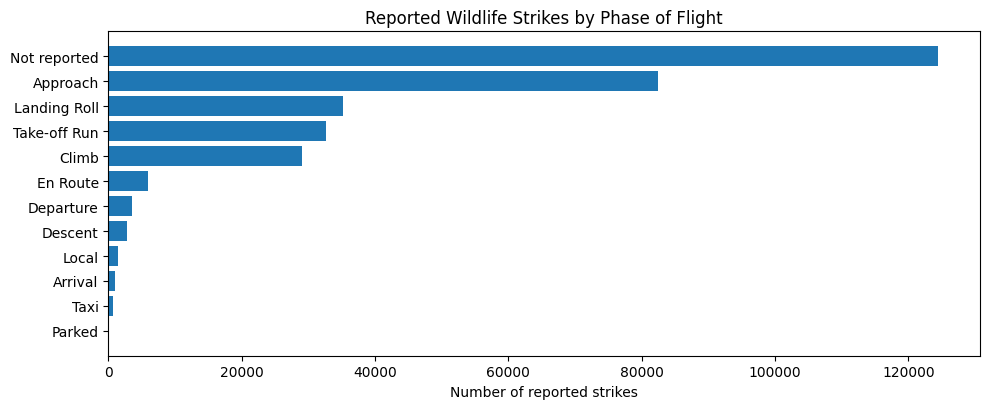

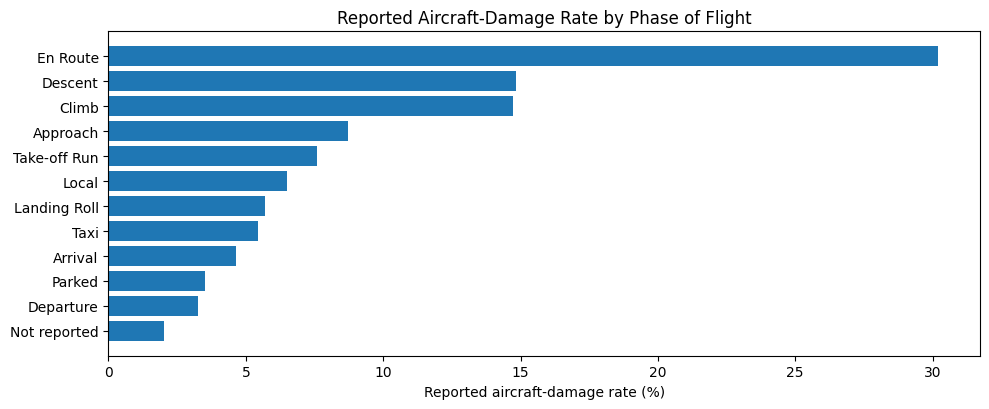

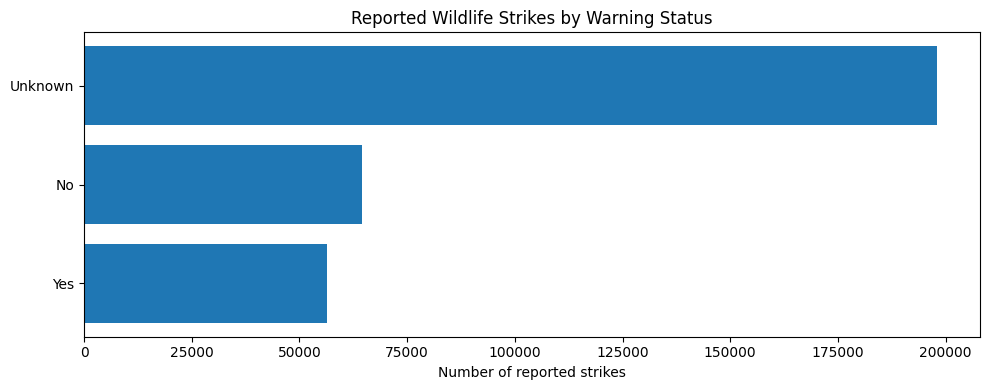

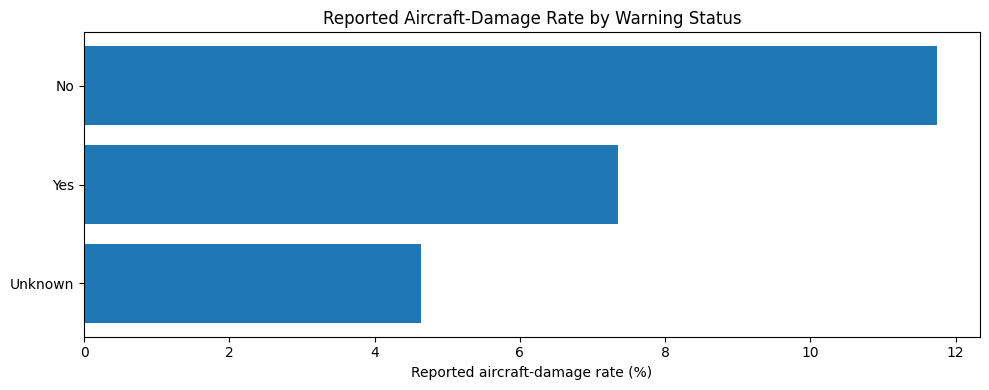

In [10]:

figure_specs = [
    ("temporal_season", "SEASON", "Season", None, 1),
    ("temporal_time_of_day", "TIME_OF_DAY", "Time of Day", None, 1),
    ("geographic_faa_region", "FAAREGION", "FAA Region", None, 50),
    ("wildlife_wildlife_type", "WILDLIFE_TYPE", "Broad Wildlife Type", None, 1),
    ("wildlife_wildlife_size", "SIZE", "Wildlife Size", None, 1),
    ("wildlife_number_struck", "NUM_STRUCK", "Number of Wildlife Struck", None, 1),
    ("aircraft_aircraft_class", "AC_CLASS", "Aircraft Class", None, 30),
    ("aircraft_aircraft_mass_group", "AC_MASS_GROUP", "Aircraft Mass Group", None, 1),
    ("aircraft_engine_type", "TYPE_ENG", "Engine Type", None, 30),
    ("aircraft_number_of_engines", "NUM_ENGS", "Number of Engines", None, 30),
    ("flight_phase_of_flight", "PHASE_OF_FLIGHT", "Phase of Flight", None, 30),
    ("flight_warning_status", "WARNED", "Warning Status", None, 1),
]

for key, column, label, top_n, minimum_records in figure_specs:
    if key not in summary_tables:
        continue
    plot_counts(
        summary_tables[key],
        column,
        f"Reported Wildlife Strikes by {label}",
        f"{key}_counts.png",
        top_n=top_n,
    )
    plot_damage_rates(
        summary_tables[key],
        column,
        f"Reported Aircraft-Damage Rate by {label}",
        f"{key}_damage_rate.png",
        top_n=top_n,
        minimum_records=minimum_records,
    )


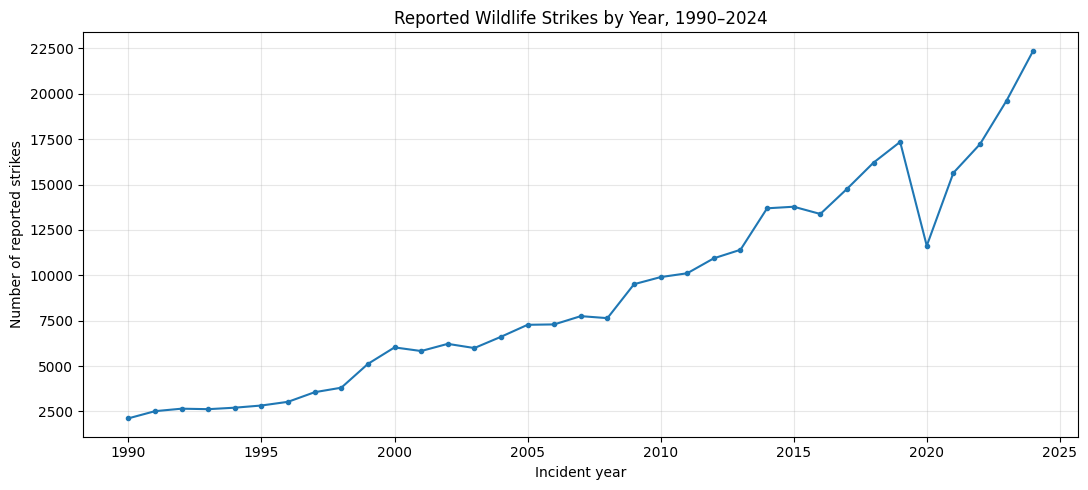

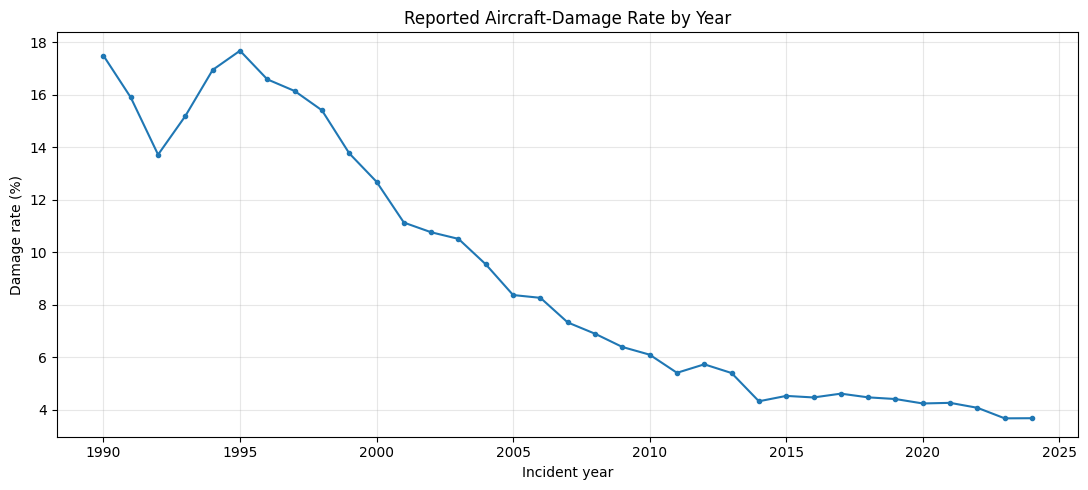

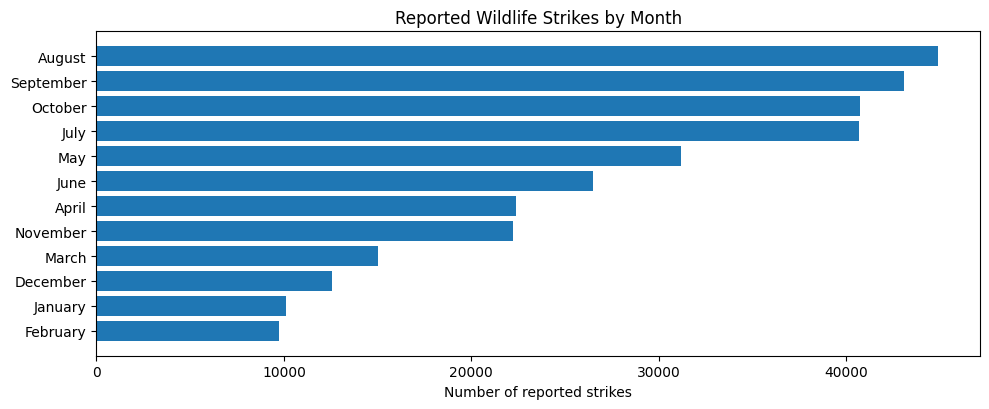

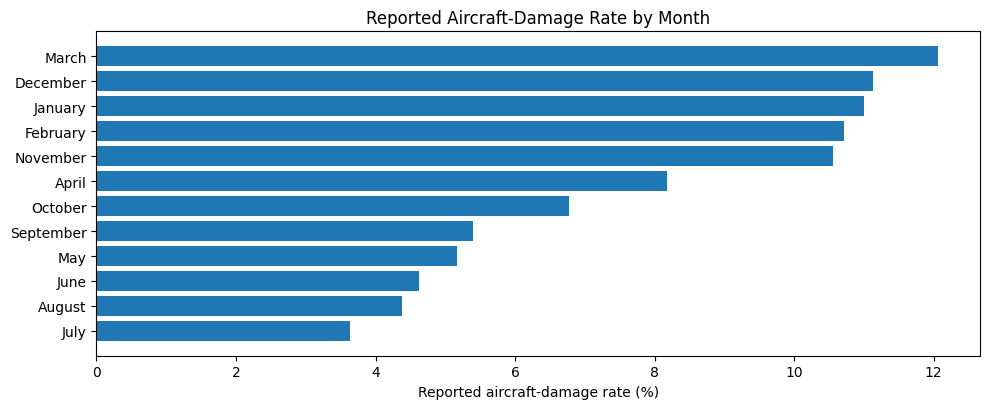

In [11]:

# Annual trend: separate count and rate figures.
yearly_summary = summary_tables["temporal_incident_year"].sort_values(
    "INCIDENT_YEAR"
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly_summary["INCIDENT_YEAR"], yearly_summary["Reported_Strikes"], marker="o", markersize=3)
ax.set_title("Reported Wildlife Strikes by Year, 1990–2024")
ax.set_xlabel("Incident year")
ax.set_ylabel("Number of reported strikes")
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, "temporal_annual_reported_strikes.png")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly_summary["INCIDENT_YEAR"], yearly_summary["Damage_Rate_Pct"], marker="o", markersize=3)
ax.set_title("Reported Aircraft-Damage Rate by Year")
ax.set_xlabel("Incident year")
ax.set_ylabel("Damage rate (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, "temporal_annual_damage_rate.png")
plt.show()

# Month labels are added only for communication.
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December",
}
monthly_summary = summary_tables["temporal_incident_month"].copy()
monthly_summary["Month"] = monthly_summary["INCIDENT_MONTH"].map(month_names)
save_table(monthly_summary, "temporal_incident_month_labelled.csv")

plot_counts(
    monthly_summary,
    "Month",
    "Reported Wildlife Strikes by Month",
    "temporal_month_counts.png",
)
plot_damage_rates(
    monthly_summary,
    "Month",
    "Reported Aircraft-Damage Rate by Month",
    "temporal_month_damage_rate.png",
)


In [12]:
# Display annual temporal summary
display(
    yearly_summary[
        [
            "INCIDENT_YEAR",
            "Reported_Strikes",
            "Damage_Records",
            "No_Damage_Records",
            "Damage_Rate_Pct",
            "Damage_Rate_CI95_Lower",
            "Damage_Rate_CI95_Upper",
        ]
    ]
)

,INCIDENT_YEAR,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
34,1990,2120,371,1749,17.5,15.941718,19.175854
33,1991,2515,400,2115,15.904573,14.527381,17.385765
31,1992,2652,364,2288,13.72549,12.468148,15.087772
32,1993,2625,399,2226,15.2,13.877472,16.624237
30,1994,2707,459,2248,16.95604,15.589488,18.416247
29,1995,2827,500,2327,17.686594,16.324180,19.136709
28,1996,3031,503,2528,16.595183,15.313138,17.961798
27,1997,3560,575,2985,16.151685,14.979382,17.396962
26,1998,3808,587,3221,15.414916,14.302921,16.596621
25,1999,5118,705,4413,13.774912,12.857839,14.746326


In [13]:
# Display monthly temporal summary
display(
    monthly_summary[
        [
            "INCIDENT_MONTH",
            "Month",
            "Reported_Strikes",
            "Damage_Records",
            "No_Damage_Records",
            "Damage_Rate_Pct",
            "Damage_Rate_CI95_Lower",
            "Damage_Rate_CI95_Upper",
        ]
    ]
)

,INCIDENT_MONTH,Month,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,1,January,10121,1114,9007,11.006818,10.411796,11.631429
1,2,February,9732,1043,8689,10.717222,10.118065,11.347378
2,3,March,15000,1809,13191,12.06,11.548523,12.590906
3,4,April,22363,1828,20535,8.174216,7.822275,8.540525
4,5,May,31194,1610,29584,5.161249,4.921201,5.412339
5,6,June,26488,1223,25265,4.617185,4.370970,4.876563
6,7,July,40680,1480,39200,3.638151,3.460532,3.824526
7,8,August,44894,1964,42930,4.374749,4.189419,4.567887
8,9,September,43087,2327,40760,5.400701,5.191221,5.618133
9,10,October,40713,2759,37954,6.776705,6.536608,7.024958


### Temporal patterns

The annual number of reported wildlife strikes increased substantially from 1990 to 2024, with a sharp temporary decline in 2020 followed by a strong recovery to the highest recorded level in 2024. In contrast, the reported aircraft-damage rate generally declined over time, falling from approximately 17–18% in the early 1990s to below 4% in the most recent years.

Monthly patterns also show that strike frequency and damage consequences do not follow the same distribution. Reported strikes were most frequent from July to October, particularly in August and September, whereas the highest damage rates occurred during the colder months, especially March, December, January, and February. These results describe trends among reported strikes and may also reflect changes in reporting practices and operational conditions over time.

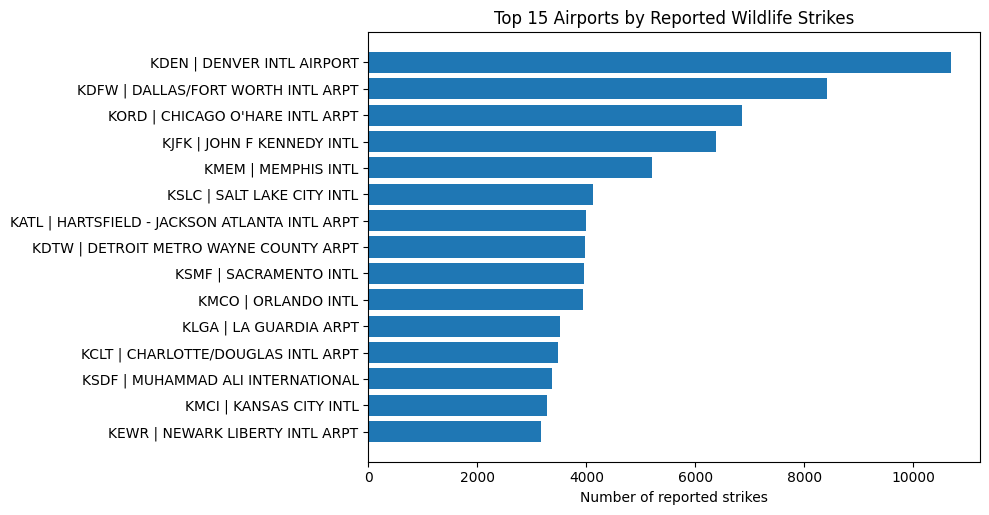

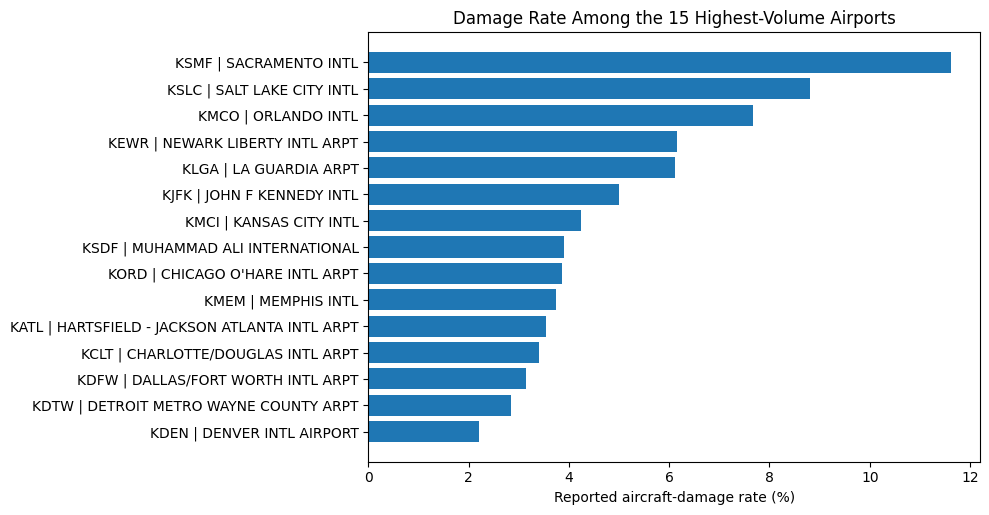

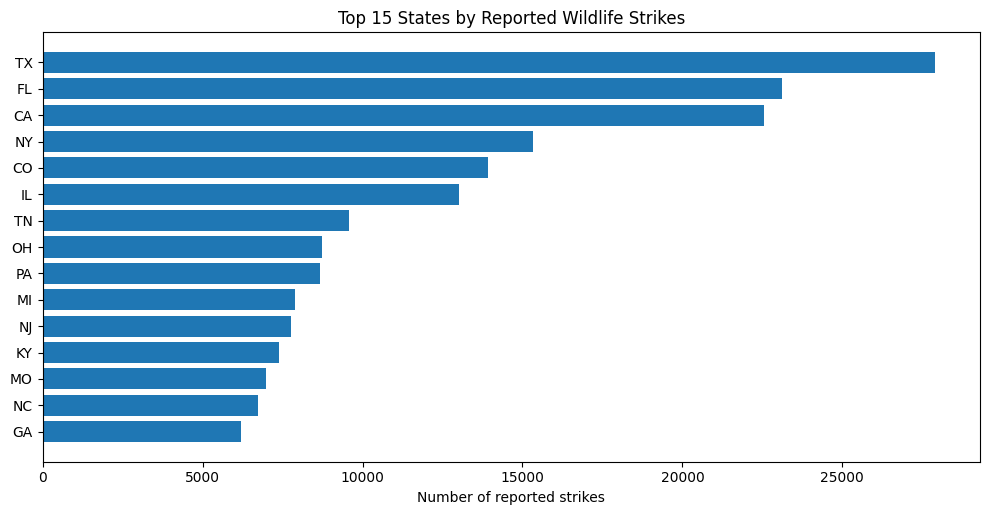

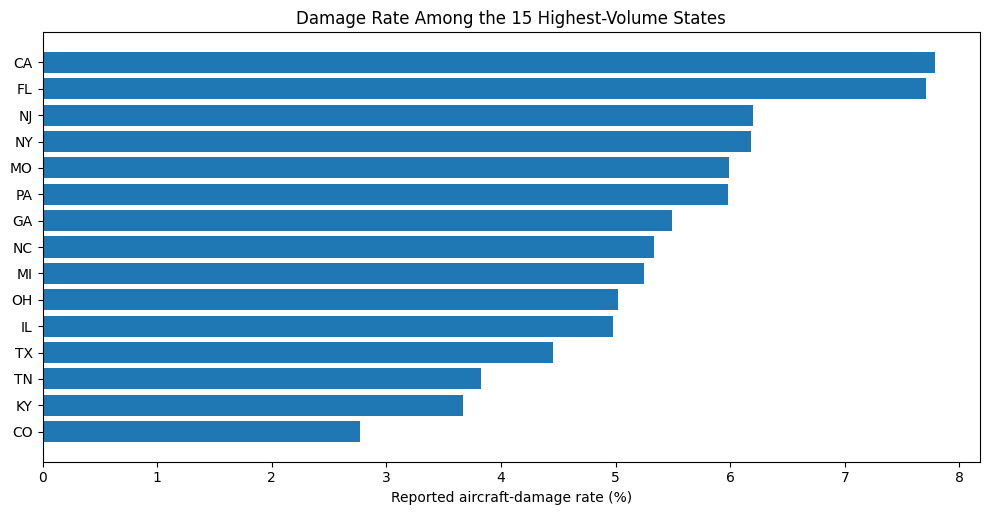

In [14]:

# High-cardinality figures: top categories by reporting volume.
if "geographic_airport" in summary_tables:
    valid_airports = summary_tables["geographic_airport"].copy()
    invalid_airport_ids = {"UNKNOWN", "UNK", "ZZZZ", "NOT REPORTED"}
    valid_airports = valid_airports.loc[
        ~valid_airports["AIRPORT_ID"]
        .astype("string")
        .str.strip()
        .str.upper()
        .isin(invalid_airport_ids)
    ]
    plot_counts(
        valid_airports,
        ["AIRPORT_ID", "AIRPORT"],
        "Top 15 Airports by Reported Wildlife Strikes",
        "geographic_top15_airports_counts.png",
        top_n=15,
    )
    plot_damage_rates(
        valid_airports,
        ["AIRPORT_ID", "AIRPORT"],
        "Damage Rate Among the 15 Highest-Volume Airports",
        "geographic_top15_airports_damage_rate.png",
        top_n=15,
        minimum_records=200,
    )

if "geographic_state" in summary_tables:
    state_summary = summary_tables["geographic_state"].copy()
    invalid_state_labels = {"UNKNOWN", "UNK", "NOT REPORTED"}
    state_summary = state_summary.loc[
        ~state_summary["STATE"]
        .astype("string")
        .str.strip()
        .str.upper()
        .isin(invalid_state_labels)
    ]
    plot_counts(
        state_summary,
        "STATE",
        "Top 15 States by Reported Wildlife Strikes",
        "geographic_top15_states_counts.png",
        top_n=15,
    )
    plot_damage_rates(
        state_summary,
        "STATE",
        "Damage Rate Among the 15 Highest-Volume States",
        "geographic_top15_states_damage_rate.png",
        top_n=15,
        minimum_records=200,
    )



### Geographic patterns

Reported strike volume and damage rate did not follow the same geographic pattern. Denver International recorded the largest number of strikes among the 15 highest-volume airports, but one of the lowest damage rates in this group. In contrast, Sacramento, Salt Lake City, and Orlando showed higher damage rates despite lower reporting volumes.

Texas, Florida, and California recorded the largest numbers of reported strikes. However, California and Florida had the highest damage rates among the 15 highest-volume states, while Texas had a comparatively lower rate. These results should not be interpreted as geographic risk because the analysis does not account for aircraft movements, airport size, or reporting differences.

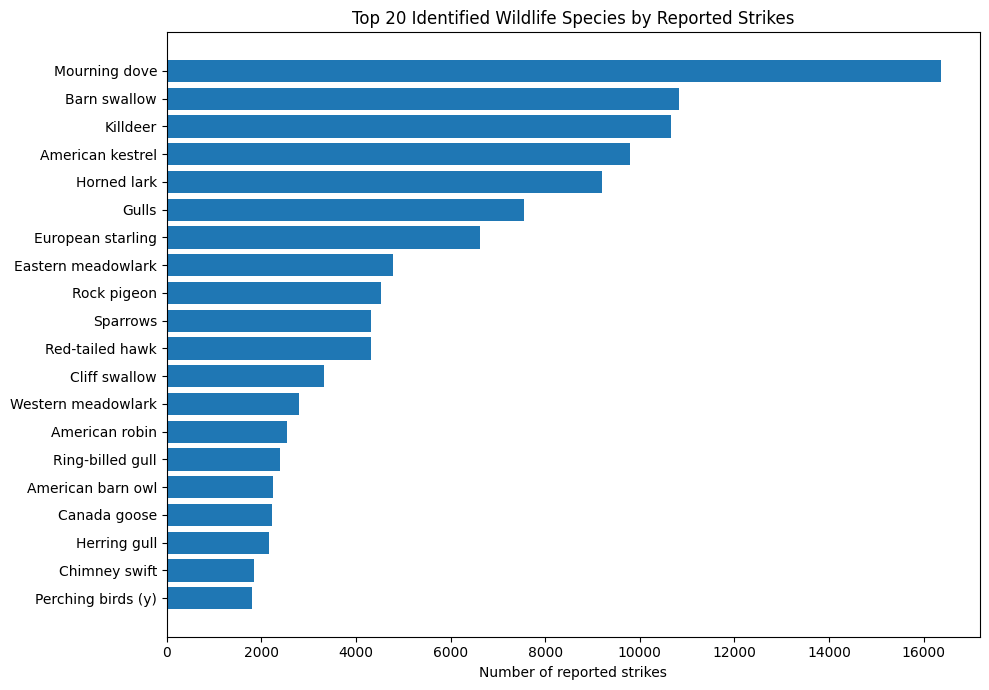

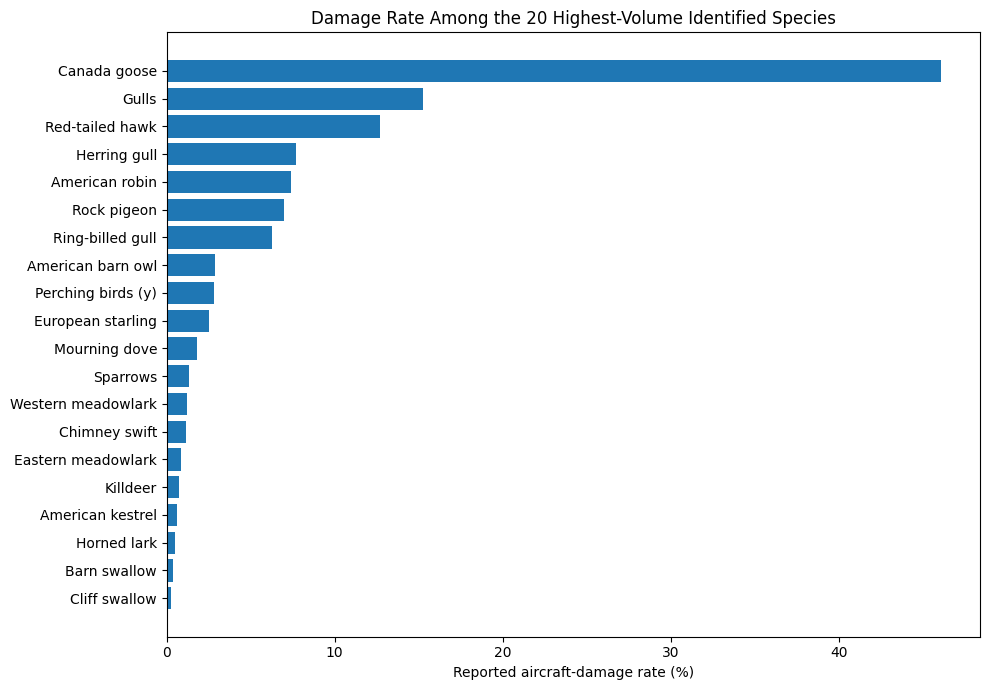

In [15]:
if "wildlife_exact_species" in summary_tables:
    species_summary = summary_tables["wildlife_exact_species"].copy()
    unknown_species = species_summary["SPECIES"].astype("string").str.contains(
        "unknown|not reported", case=False, na=False
    )
    identified_species = species_summary.loc[~unknown_species]
    plot_counts(
        identified_species,
        "SPECIES",
        "Top 20 Identified Wildlife Species by Reported Strikes",
        "wildlife_top20_species_counts.png",
        top_n=20,
    )
    plot_damage_rates(
        identified_species,
        "SPECIES",
        "Damage Rate Among the 20 Highest-Volume Identified Species",
        "wildlife_top20_species_damage_rate.png",
        top_n=20,
        minimum_records=200,
    )


### Species patterns

The most frequently reported identified species were mourning doves, barn swallows, killdeer, and American kestrels. However, the most frequently struck species did not necessarily have the highest damage rates.

Among the 20 highest-volume identified species, Canada geese had by far the highest damage rate, followed by gulls and red-tailed hawks. Several commonly reported smaller bird species had relatively low damage rates. This pattern is consistent with the broader descriptive finding that wildlife size is associated with reported aircraft damage.

## 7. Cross-factor descriptive analysis

This section examines how damage rates vary across selected combinations of wildlife, aircraft, seasonal, and flight characteristics. The results provide an initial view of possible interaction patterns, which will be examined further during the modelling stage.

In [16]:

interaction_tables = {}

def build_interaction_table(data, row_field, column_field, filename):
    required = {row_field, column_field, "INDEX_NR", "INDICATED_DAMAGE"}
    if not required.issubset(data.columns):
        warnings.warn(
            f"Skipping interaction {row_field} × {column_field}; "
            "one or more fields are unavailable."
        )
        return None

    table = (
        data.groupby([row_field, column_field], dropna=False)
        .agg(
            Reported_Strikes=("INDEX_NR", "size"),
            Damage_Records=("INDICATED_DAMAGE", "sum"),
        )
        .reset_index()
    )
    table["Damage_Rate_Pct"] = (
        table["Damage_Records"] / table["Reported_Strikes"] * 100
    )
    lower, upper = wilson_interval(
        table["Damage_Records"], table["Reported_Strikes"]
    )
    table["Damage_Rate_CI95_Lower"] = lower
    table["Damage_Rate_CI95_Upper"] = upper
    save_table(table, filename)
    interaction_tables[filename] = table
    return table

wildlife_season = build_interaction_table(
    analysis_df,
    "WILDLIFE_TYPE",
    "SEASON",
    "interaction_wildlife_type_by_season.csv",
)

size_mass = build_interaction_table(
    analysis_df,
    "SIZE",
    "AC_MASS_GROUP",
    "interaction_wildlife_size_by_aircraft_mass_group.csv",
)

size_phase = build_interaction_table(
    analysis_df,
    "SIZE",
    "PHASE_OF_FLIGHT",
    "interaction_wildlife_size_by_phase_of_flight.csv",
)

if {"AIRPORT_ID", "AIRPORT", "SEASON"}.issubset(analysis_df.columns):
    top_airport_ids = (
        analysis_df.loc[
            ~analysis_df["AIRPORT_ID"]
            .astype("string")
            .str.strip()
            .str.upper()
            .isin({"UNKNOWN", "UNK", "ZZZZ", "NOT REPORTED"})
        ]
        .groupby("AIRPORT_ID")
        .size()
        .nlargest(15)
        .index
    )
    top_airport_data = analysis_df.loc[
        analysis_df["AIRPORT_ID"].isin(top_airport_ids)
    ].copy()

    airport_season = (
        top_airport_data
        .groupby(["AIRPORT_ID", "AIRPORT", "SEASON"], dropna=False)
        .agg(
            Reported_Strikes=("INDEX_NR", "size"),
            Damage_Records=("INDICATED_DAMAGE", "sum"),
        )
        .reset_index()
    )
    airport_season["Damage_Rate_Pct"] = (
        airport_season["Damage_Records"]
        / airport_season["Reported_Strikes"]
        * 100
    )
    lower, upper = wilson_interval(
        airport_season["Damage_Records"],
        airport_season["Reported_Strikes"],
    )
    airport_season["Damage_Rate_CI95_Lower"] = lower
    airport_season["Damage_Rate_CI95_Upper"] = upper
    save_table(
        airport_season,
        "interaction_top15_airports_by_season.csv",
    )
    interaction_tables[
        "interaction_top15_airports_by_season.csv"
    ] = airport_season

if wildlife_season is not None:
    wildlife_season_pivot = wildlife_season.pivot_table(
        index="WILDLIFE_TYPE",
        columns="SEASON",
        values="Damage_Rate_Pct",
        aggfunc="first",
    )
    wildlife_season_pivot.to_csv(
        TABLE_DIR / "interaction_wildlife_type_by_season_damage_rate_matrix.csv"
    )
    output_manifest.append({
        "artifact_type": "table",
        "filename": "interaction_wildlife_type_by_season_damage_rate_matrix.csv",
        "relative_path": str(
            (
                TABLE_DIR
                / "interaction_wildlife_type_by_season_damage_rate_matrix.csv"
            ).relative_to(ROOT)
        ),
        "rows": len(wildlife_season_pivot),
        "columns": wildlife_season_pivot.shape[1],
    })
    display(wildlife_season_pivot)

if size_mass is not None:
    display(
        size_mass.sort_values(
            ["SIZE", "Reported_Strikes"],
            ascending=[True, False],
        )
    )

if size_phase is not None:
    display(
        size_phase.sort_values(
            ["SIZE", "Reported_Strikes"],
            ascending=[True, False],
        ).head(40)
    )


SEASON,Autumn,Spring,Summer,Winter
WILDLIFE_TYPE,,,,
Bat,1.162791,0.982318,0.751174,2.542373
Bird,7.289044,7.903873,4.317783,11.18334
Other wildlife,5.513963,6.549288,3.321,9.650053
Reptile,0.0,0.985222,0.607903,0.0
Terrestrial mammal,9.470069,9.094126,5.086951,11.819116


,SIZE,AC_MASS_GROUP,Reported_Strikes,Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Large,Heavy,7226,2341,32.3969,31.327448,33.485059
3,Large,Unknown,5271,50,0.948587,0.720293,1.248328
1,Large,Light,4461,2960,66.352836,64.952714,67.724817
2,Large,Medium,2643,1109,41.959894,40.091460,43.851667
4,Medium,Heavy,43122,5061,11.736469,11.436087,12.043667
7,Medium,Unknown,12847,79,0.61493,0.493724,0.765661
6,Medium,Medium,8467,1473,17.396953,16.604317,18.219160
5,Medium,Light,6874,2366,34.419552,33.305376,35.551133
8,Not reported,Heavy,22579,708,3.135657,2.916182,3.371076
10,Not reported,Medium,4227,229,5.417554,4.774732,6.141337


,SIZE,PHASE_OF_FLIGHT,Reported_Strikes,Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Large,Approach,5423,2380,43.887147,42.571138,45.211811
8,Large,Not reported,5331,118,2.213468,1.851588,2.644171
6,Large,Landing Roll,2945,1167,39.626486,37.874535,41.405465
2,Large,Climb,2456,1341,54.600977,52.626228,56.561356
10,Large,Take-off Run,2188,706,32.26691,30.340565,34.255417
5,Large,En Route,737,575,78.018996,74.888101,80.859309
4,Large,Descent,196,99,50.510204,43.568358,57.432435
11,Large,Taxi,118,19,16.101695,10.557198,23.783782
7,Large,Local,105,27,25.714286,18.315792,34.827124
3,Large,Departure,68,18,26.470588,17.449603,38.007959


### Cross-factor patterns

Damage rates varied across combinations of wildlife, aircraft, season, and flight characteristics. For most wildlife groups, winter had the highest damage rate, while summer generally had the lowest. Birds and terrestrial mammals also showed higher rates than bats and reptiles.

Among records with known aircraft mass, damage rates increased with wildlife size and were consistently highest for light aircraft. For large-wildlife strikes, the damage rate was 66.4% for light aircraft, 42.0% for medium aircraft, and 32.4% for heavy aircraft. The very low rates in the `Unknown` aircraft-mass group likely reflect missing or incomplete aircraft information and should not be interpreted as lower risk.

The pattern also varied across phases of flight. Large-wildlife strikes had particularly high damage rates during en route, climb, descent, and approach, while small-wildlife strikes generally had much lower rates. These results highlight possible interaction patterns for further modelling, but they remain descriptive and do not establish causal or independent effects.

In [17]:
def plot_damage_rate_heatmap(
    table,
    row_field,
    column_field,
    title,
    filename,
    row_order=None,
    column_order=None,
):
    plot_data = table.copy()

    # Exclude unavailable categories from the figure only.
    unavailable = {"Unknown", "Not reported"}

    plot_data = plot_data.loc[
        ~plot_data[row_field].astype(str).isin(unavailable)
        & ~plot_data[column_field].astype(str).isin(unavailable)
    ]

    matrix = plot_data.pivot_table(
        index=row_field,
        columns=column_field,
        values="Damage_Rate_Pct",
        aggfunc="first",
    )

    if row_order is not None:
        valid_rows = [
            value for value in row_order
            if value in matrix.index
        ]
        matrix = matrix.reindex(valid_rows)

    if column_order is not None:
        valid_columns = [
            value for value in column_order
            if value in matrix.columns
        ]
        matrix = matrix.reindex(columns=valid_columns)

    fig, ax = plt.subplots(
        figsize=(
            max(8, matrix.shape[1] * 1.2),
            max(4, matrix.shape[0] * 0.7),
        )
    )

    image = ax.imshow(
        matrix.to_numpy(dtype=float),
        aspect="auto",
    )

    ax.set_xticks(range(matrix.shape[1]))
    ax.set_xticklabels(
        matrix.columns,
        rotation=45,
        ha="right",
    )

    ax.set_yticks(range(matrix.shape[0]))
    ax.set_yticklabels(matrix.index)

    # Display the damage rate inside each cell.
    for row_position in range(matrix.shape[0]):
        for column_position in range(matrix.shape[1]):
            value = matrix.iloc[
                row_position,
                column_position
            ]

            if pd.notna(value):
                ax.text(
                    column_position,
                    row_position,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                )

    ax.set_title(title)
    ax.set_xlabel(column_field.replace("_", " ").title())
    ax.set_ylabel(row_field.replace("_", " ").title())

    fig.colorbar(
        image,
        ax=ax,
        label="Reported aircraft-damage rate (%)",
    )

    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()

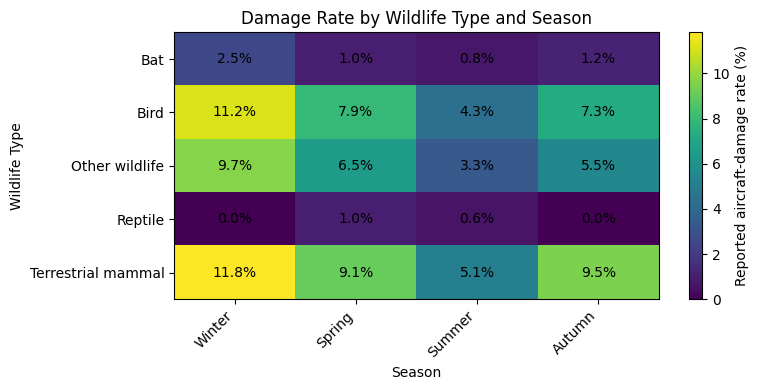

In [18]:
plot_damage_rate_heatmap(
    wildlife_season,
    row_field="WILDLIFE_TYPE",
    column_field="SEASON",
    title="Damage Rate by Wildlife Type and Season",
    filename="interaction_wildlife_type_by_season_heatmap.png",
    column_order=[
        "Winter",
        "Spring",
        "Summer",
        "Autumn",
    ],
)

Damage rates were generally highest in winter and lowest in summer. Terrestrial mammals and birds showed the highest rates across seasons, while bats and reptiles had much lower rates. Results for low-volume wildlife groups should be interpreted cautiously.

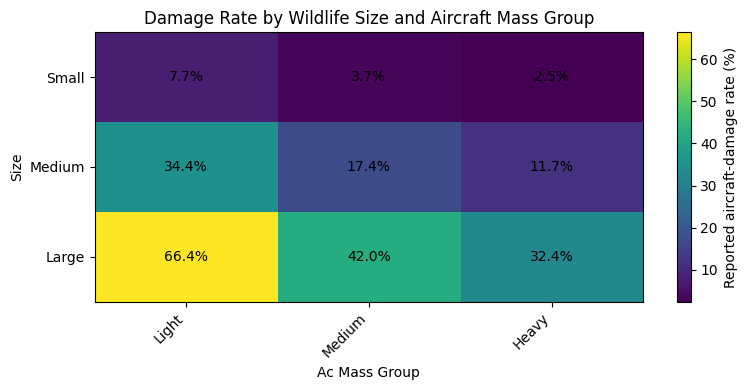

In [19]:
plot_damage_rate_heatmap(
    size_mass,
    row_field="SIZE",
    column_field="AC_MASS_GROUP",
    title="Damage Rate by Wildlife Size and Aircraft Mass Group",
    filename="interaction_size_by_aircraft_mass_heatmap.png",
    row_order=[
        "Small",
        "Medium",
        "Large",
    ],
    column_order=[
        "Light",
        "Medium",
        "Heavy",
    ],
)

Damage rates increased with wildlife size across all aircraft mass groups. Within each wildlife-size category, light aircraft consistently had higher damage rates than medium and heavy aircraft, with the largest difference observed for large-wildlife strikes.

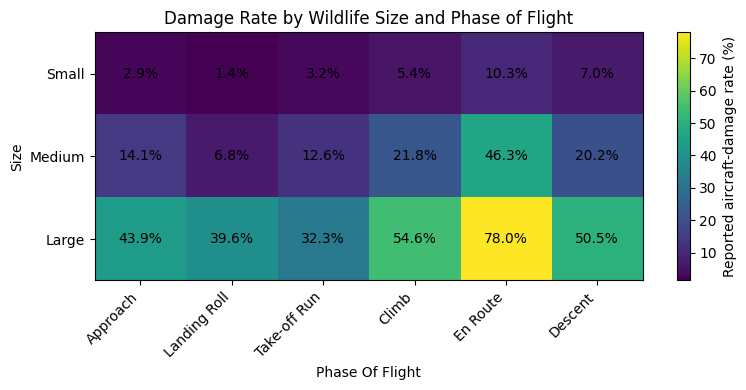

In [20]:
main_phases = [
    "Approach",
    "Landing Roll",
    "Take-off Run",
    "Climb",
    "En Route",
    "Descent",
]

size_phase_figure = size_phase.loc[
    size_phase["PHASE_OF_FLIGHT"].isin(main_phases)
].copy()

plot_damage_rate_heatmap(
    size_phase_figure,
    row_field="SIZE",
    column_field="PHASE_OF_FLIGHT",
    title="Damage Rate by Wildlife Size and Phase of Flight",
    filename="interaction_size_by_flight_phase_heatmap.png",
    row_order=[
        "Small",
        "Medium",
        "Large",
    ],
    column_order=main_phases,
)

Damage rates increased consistently with wildlife size across all selected phases of flight. En-route strikes showed the highest rates, reaching 78.0% for large wildlife and 46.3% for medium wildlife, while climb and descent also showed elevated rates. However, some phase–size combinations had fewer records, so these descriptive patterns should be reviewed together with their confidence intervals and should not be interpreted as causal effects.

## 8. Numerical flight-context analysis

This section compares recorded height, speed, and distance overall and by damage status. Missing values and unusual observations identified in Notebook 02 are kept for review rather than removed automatically.

In [21]:

numeric_fields = [
    field for field in ["HEIGHT", "SPEED", "DISTANCE"]
    if field in analysis_df.columns
]

numeric_overall_rows = []
numeric_by_damage_rows = []

for field in numeric_fields:
    values = pd.to_numeric(analysis_df[field], errors="coerce")

    numeric_overall_rows.append({
        "Variable": field,
        "Available_Records": int(values.notna().sum()),
        "Missing_Records": int(values.isna().sum()),
        "Missing_Percentage": values.isna().mean() * 100,
        "Mean": values.mean(),
        "Standard_Deviation": values.std(),
        "Minimum": values.min(),
        "P25": values.quantile(0.25),
        "Median": values.median(),
        "P75": values.quantile(0.75),
        "P99": values.quantile(0.99),
        "Maximum": values.max(),
    })

    for damage_value, label in [(0, "No damage reported"), (1, "Damage reported")]:
        group_values = values.loc[
            analysis_df["INDICATED_DAMAGE"].eq(damage_value)
        ].dropna()
        numeric_by_damage_rows.append({
            "Variable": field,
            "Damage_Status": label,
            "Available_Records": len(group_values),
            "Mean": group_values.mean(),
            "Standard_Deviation": group_values.std(),
            "P25": group_values.quantile(0.25),
            "Median": group_values.median(),
            "P75": group_values.quantile(0.75),
        })

numeric_overall_summary = pd.DataFrame(numeric_overall_rows)
numeric_by_damage_summary = pd.DataFrame(numeric_by_damage_rows)

save_table(numeric_overall_summary, "flight_numeric_overall_summary.csv")
save_table(numeric_by_damage_summary, "flight_numeric_summary_by_damage.csv")

display(numeric_overall_summary)
display(numeric_by_damage_summary)


,Variable,Available_Records,Missing_Records,Missing_Percentage,Mean,Standard_Deviation,Minimum,P25,Median,P75,P99,Maximum
0,HEIGHT,160917,158190,49.572714,876.909289,1853.047706,0.0,0.0,50.0,900.0,9000.0,32000.0
1,SPEED,100786,218321,68.416237,142.831088,46.456937,0.0,120.0,140.0,160.0,250.0,541.0
2,DISTANCE,212053,107054,33.547995,0.854350,3.648005,0.0,0.0,0.0,0.0,20.0,99.0


,Variable,Damage_Status,Available_Records,Mean,Standard_Deviation,P25,Median,P75
0,HEIGHT,No damage reported,145111,824.013093,1775.665320,0.0,25.0,800.0
1,HEIGHT,Damage reported,15806,1362.536252,2398.030904,0.0,400.0,1700.0
2,SPEED,No damage reported,89058,143.001100,45.382554,120.0,140.0,160.0
3,SPEED,Damage reported,11728,141.540075,53.906112,100.0,135.0,170.0
4,DISTANCE,No damage reported,202314,0.779367,3.448310,0.0,0.0,0.0
5,DISTANCE,Damage reported,9739,2.412029,6.340903,0.0,0.0,1.0


In [22]:
def plot_numeric_by_damage(data, variable, title, filename):
    plot_data = data[[variable, "INDICATED_DAMAGE"]].copy()

    plot_data[variable] = pd.to_numeric(
        plot_data[variable],
        errors="coerce"
    )

    plot_data = plot_data.dropna(
        subset=[variable, "INDICATED_DAMAGE"]
    )

    # Limit the displayed range to P99 for readability only.
    upper_limit = plot_data[variable].quantile(0.99)

    figure_data = plot_data.loc[
        plot_data[variable] <= upper_limit
    ].copy()

    figure_data["Damage_Status"] = (
        figure_data["INDICATED_DAMAGE"]
        .map({
            0: "No damage reported",
            1: "Damage reported",
        })
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    figure_data.boxplot(
        column=variable,
        by="Damage_Status",
        ax=ax,
        grid=False,
    )

    ax.set_title(title)
    ax.set_xlabel("Damage status")
    ax.set_ylabel(variable.replace("_", " ").title())

    fig.suptitle("")
    plt.tight_layout()

    save_figure(fig, filename)
    plt.show()

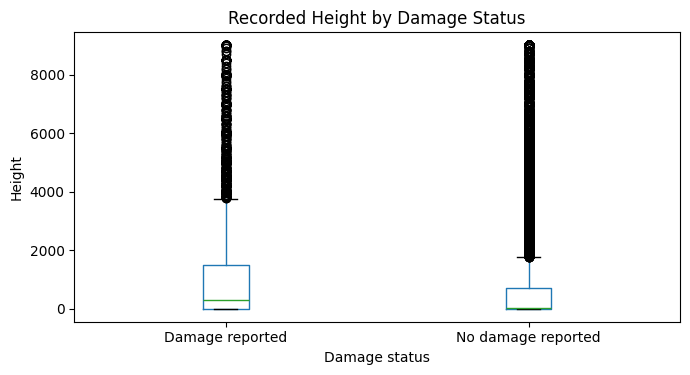

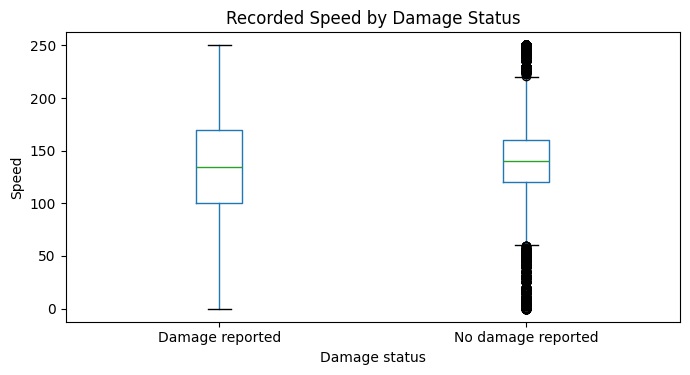

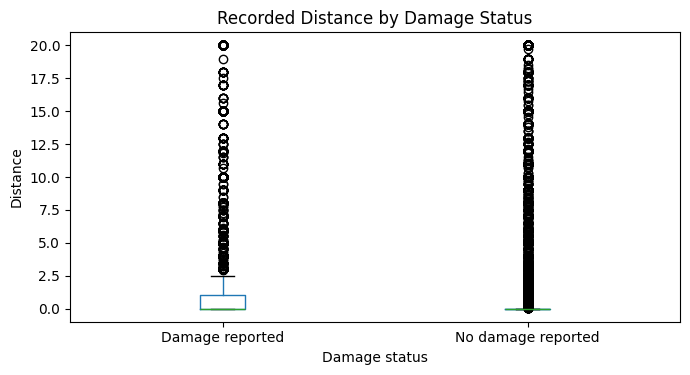

In [23]:
plot_numeric_by_damage(
    analysis_df,
    variable="HEIGHT",
    title="Recorded Height by Damage Status",
    filename="flight_height_by_damage_status.png",
)

plot_numeric_by_damage(
    analysis_df,
    variable="SPEED",
    title="Recorded Speed by Damage Status",
    filename="flight_speed_by_damage_status.png",
)

plot_numeric_by_damage(
    analysis_df,
    variable="DISTANCE",
    title="Recorded Distance by Damage Status",
    filename="flight_distance_by_damage_status.png",
)

### Numerical flight-context patterns

Height, speed, and distance had substantial missingness, especially speed (68.4%) and height (49.6%). Therefore, these variables should be interpreted cautiously.

Damaging strikes occurred at higher recorded heights than non-damaging strikes, with median values of 400 and 25, respectively. Recorded distance was also higher for damaging strikes, although the median was zero in both groups and most observations were concentrated near zero. Speed showed only a small difference in median values, but damaging strikes had a wider spread.

Because these variables are skewed and contain extreme values, medians and interquartile ranges are more informative than means. Formal differences should be evaluated using the statistical tests and effect sizes reported later in the notebook.

## 9. Secondary consequence analysis

This section summarizes damage severity, affected aircraft components, and reported injuries and fatalities. Because these variables describe consequences observed after a strike, they are excluded from the predictors used in the primary binary damage model to prevent data leakage. Cost variables were not analyzed because their formats had not yet been fully converted and validated.

,DAMAGE_LEVEL,Damage_Records,Severity,Percentage_Among_Damaged
0,M,8657,Minor,41.405204
1,M?,7818,Damage reported; level undetermined,37.392386
2,S,4344,Substantial,20.776736
3,D,89,Destroyed,0.425674


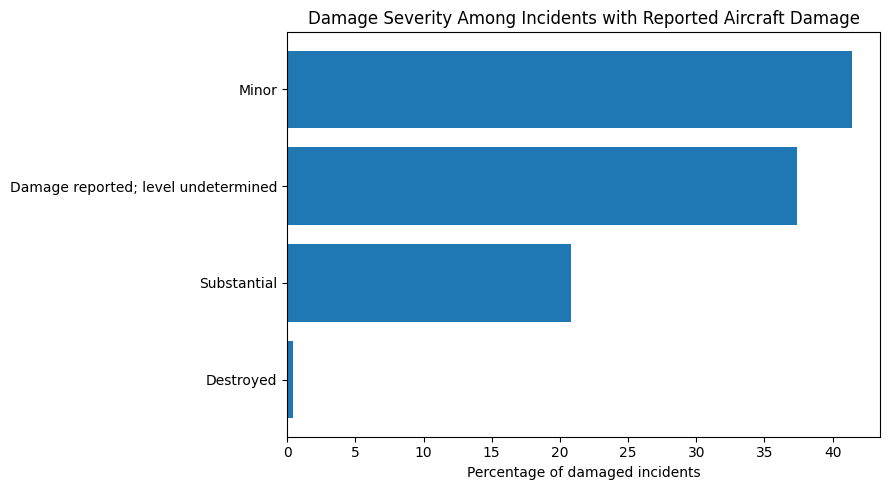

,Component_Field,Damage_Records,Percentage_of_All_Reported_Strikes
8,DAM_WING_ROT,6296,1.973006
3,DAM_ENG1,3085,0.966760
4,DAM_ENG2,2602,0.815400
13,DAM_OTHER,2455,0.769334
0,DAM_RAD,2105,0.659653
2,DAM_NOSE,1763,0.552479
1,DAM_WINDSHLD,1468,0.460034
10,DAM_LG,1308,0.409894
9,DAM_FUSE,1209,0.378870
11,DAM_TAIL,1052,0.329670


,Impact,Incidents_with_Positive_Value,Total_Reported_Value
0,Reported injuries,294,376.0
1,Reported fatalities,25,52.0


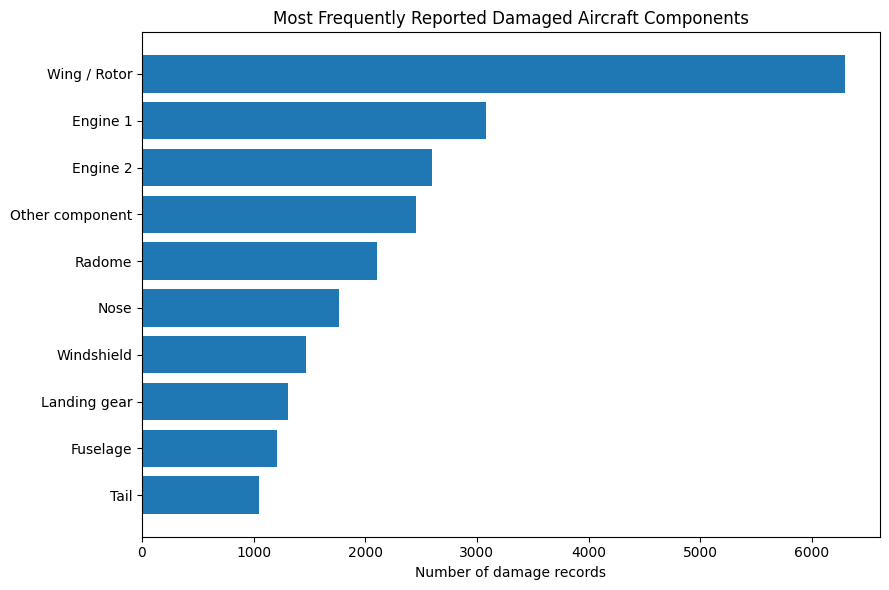

In [24]:

# Severity among damaged incidents only.
severity_labels = {
    "N": "No-damage severity code (target conflict)",
    "M": "Minor",
    "M?": "Damage reported; level undetermined",
    "S": "Substantial",
    "D": "Destroyed",
}

if "DAMAGE_LEVEL" in analysis_df.columns:
    damaged_df = analysis_df.loc[
        analysis_df["INDICATED_DAMAGE"].eq(1)
    ].copy()

    severity_summary = (
        damaged_df["DAMAGE_LEVEL"]
        .value_counts(dropna=False)
        .rename_axis("DAMAGE_LEVEL")
        .reset_index(name="Damage_Records")
    )
    severity_summary["Severity"] = (
        severity_summary["DAMAGE_LEVEL"]
        .map(severity_labels)
        .fillna(severity_summary["DAMAGE_LEVEL"].astype("string"))
    )
    severity_summary["Percentage_Among_Damaged"] = (
        severity_summary["Damage_Records"]
        / severity_summary["Damage_Records"].sum()
        * 100
    )
    save_table(severity_summary, "consequence_damage_severity_among_damaged.csv")
    display(severity_summary)

    plot_severity = severity_summary.sort_values(
        "Percentage_Among_Damaged", ascending=True
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(
        plot_severity["Severity"],
        plot_severity["Percentage_Among_Damaged"]
    )
    ax.set_title("Damage Severity Among Incidents with Reported Aircraft Damage")
    ax.set_xlabel("Percentage of damaged incidents")
    ax.set_ylabel("")
    plt.tight_layout()
    save_figure(fig, "consequence_damage_severity_among_damaged.png")
    plt.show()

# Component outcomes.
component_columns = [
    column for column in analysis_df.columns
    if column.startswith("DAM_")
    and not column.endswith(("_RAW", "_FLAG"))
]

if component_columns:
    component_summary = pd.DataFrame({
        "Component_Field": component_columns,
        "Damage_Records": [
            pd.to_numeric(analysis_df[column], errors="coerce")
            .fillna(0)
            .sum()
            for column in component_columns
        ],
    }).sort_values("Damage_Records", ascending=False)
    component_summary["Percentage_of_All_Reported_Strikes"] = (
        component_summary["Damage_Records"] / len(analysis_df) * 100
    )
    save_table(component_summary, "consequence_component_damage_summary.csv")
    display(component_summary)

# Operational, human, and cost outputs when present.
if "EFFECT" in analysis_df.columns:
    effect_summary = (
        analysis_df["EFFECT"]
        .fillna("Not reported")
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis("Effect")
        .reset_index(name="Reported_Records")
    )
    effect_summary["Percentage_of_All_Records"] = (
        effect_summary["Reported_Records"] / len(analysis_df) * 100
    )
    save_table(effect_summary, "consequence_operational_effects.csv")

impact_rows = []
for field, label in [
    ("NR_INJURIES", "Reported injuries"),
    ("NR_FATALITIES", "Reported fatalities"),
]:
    if field in analysis_df.columns:
        values = pd.to_numeric(analysis_df[field], errors="coerce").fillna(0)
        impact_rows.append({
            "Impact": label,
            "Incidents_with_Positive_Value": int((values > 0).sum()),
            "Total_Reported_Value": values.sum(),
        })
if impact_rows:
    impact_summary = pd.DataFrame(impact_rows)
    save_table(impact_summary, "consequence_injuries_fatalities.csv")
    display(impact_summary)

cost_rows = []
for field, label in [
    ("COST_REPAIRS_INFL_ADJ", "Inflation-adjusted repair cost"),
    ("COST_OTHER_INFL_ADJ", "Inflation-adjusted other cost"),
]:
    if field in analysis_df.columns:
        values = pd.to_numeric(analysis_df[field], errors="coerce")
        positive = values.loc[values > 0]
        cost_rows.append({
            "Cost_Field": field,
            "Cost_Category": label,
            "Positive_Cost_Records": int(positive.count()),
            "Total_USD": positive.sum(),
            "Median_USD": positive.median(),
            "Mean_USD": positive.mean(),
            "P95_USD": positive.quantile(0.95),
            "Maximum_USD": positive.max(),
        })

# Create clearer component labels for the figure.
component_label_map = {
    "DAM_WING_ROT": "Wing / Rotor",
    "DAM_ENG1": "Engine 1",
    "DAM_ENG2": "Engine 2",
    "DAM_ENG3": "Engine 3",
    "DAM_ENG4": "Engine 4",
    "DAM_OTHER": "Other component",
    "DAM_RAD": "Radome",
    "DAM_NOSE": "Nose",
    "DAM_WINDSHLD": "Windshield",
    "DAM_LG": "Landing gear",
    "DAM_FUSE": "Fuselage",
    "DAM_TAIL": "Tail",
    "DAM_LGHTS": "Lights",
    "DAM_PROP": "Propeller",
}

component_plot = component_summary.copy()

component_plot["Component"] = (
    component_plot["Component_Field"]
    .map(component_label_map)
    .fillna(
        component_plot["Component_Field"]
        .str.replace("DAM_", "", regex=False)
        .str.replace("_", " ", regex=False)
        .str.title()
    )
)

# Display the 10 most frequently recorded damaged components.
component_plot = (
    component_plot
    .nlargest(10, "Damage_Records")
    .sort_values("Damage_Records", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    component_plot["Component"],
    component_plot["Damage_Records"]
)

ax.set_title("Most Frequently Reported Damaged Aircraft Components")
ax.set_xlabel("Number of damage records")
ax.set_ylabel("")

plt.tight_layout()

save_figure(
    fig,
    "consequence_top10_component_damage.png"
)

plt.show()


### Secondary consequence patterns

Among the 20,908 incidents with reported aircraft damage, 41.4% were classified as minor and 20.8% as substantial, while destroyed aircraft accounted for only 0.4%. However, the damage level was undetermined in 37.4% of damaged records, which may limit the development of a detailed severity model.

Wing or rotor damage was the most frequently recorded component outcome, followed by damage to the first and second engines. Component fields are not mutually exclusive because one incident may involve damage to more than one aircraft component.

Injuries and fatalities were uncommon, with 294 incidents reporting injuries and 25 reporting fatalities. Cost fields were excluded because they had not yet been converted and validated reliably.

## 10. Predictor availability and data quality

This section evaluates the availability of key predictors used for RQ1. Explicit `Unknown` and `Not reported` categories are treated as unavailable in this diagnostic summary, but they remain visible as separate categories in the descriptive association tables.

,Variable,Available_Records,Unavailable_Records,Unavailable_Percentage
0,PRECIPITATION,11969,307138,96.249220
1,SPEED,100786,218321,68.416237
2,WARNED,121015,198092,62.076984
3,SKY,151325,167782,52.578602
4,HEIGHT,160917,158190,49.572714
5,TIME_OF_DAY,180459,138648,43.448749
6,PHASE_OF_FLIGHT,194586,124521,39.021707
7,DISTANCE,212053,107054,33.547995
8,TYPE_ENG,227849,91258,28.597931
9,NUM_ENGS,227893,91214,28.584143


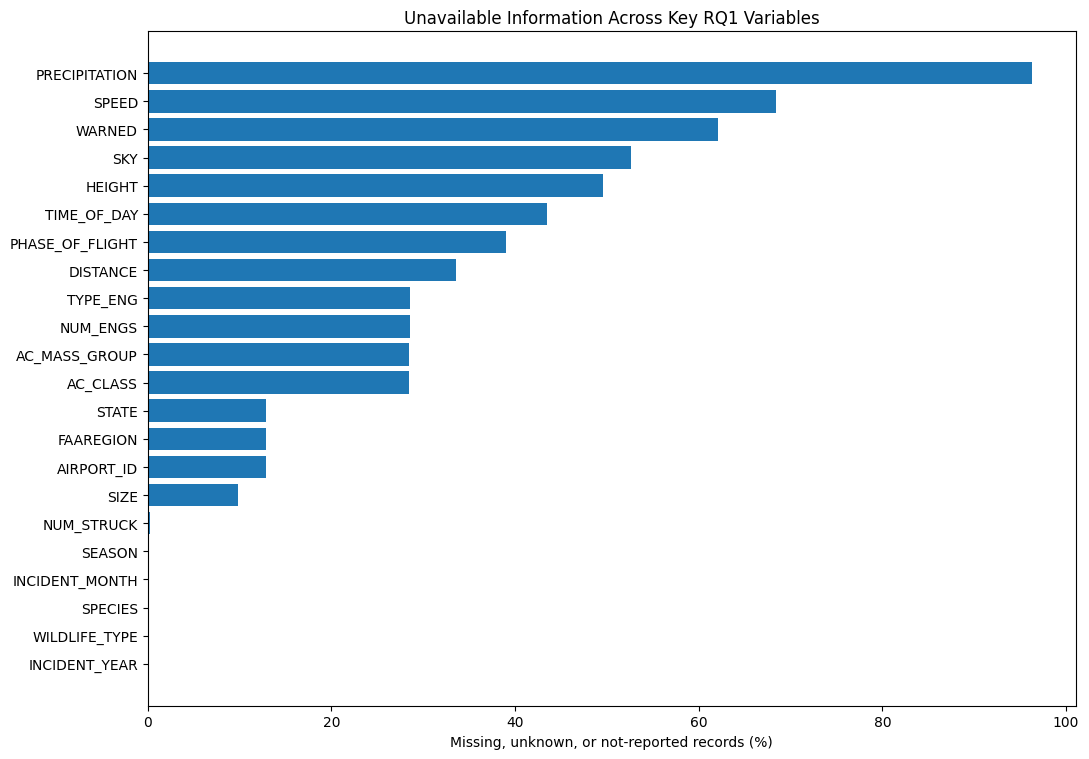

In [25]:

key_predictors = [
    "INCIDENT_YEAR",
    "INCIDENT_MONTH",
    "SEASON",
    "TIME_OF_DAY",
    "FAAREGION",
    "STATE",
    "AIRPORT_ID",
    "WILDLIFE_TYPE",
    "SPECIES",
    "SIZE",
    "NUM_STRUCK",
    "AC_CLASS",
    "AC_MASS_GROUP",
    "TYPE_ENG",
    "NUM_ENGS",
    "PHASE_OF_FLIGHT",
    "WARNED",
    "HEIGHT",
    "SPEED",
    "DISTANCE",
    "SKY",
    "PRECIPITATION",
]
key_predictors = [c for c in key_predictors if c in analysis_df.columns]

unavailable_labels = {
    "", "unknown", "unknown wildlife", "not reported",
    "unk", "zzzz", "nan", "none"
}

availability_rows = []
for field in key_predictors:
    series = analysis_df[field]
    missing_mask = series.isna()

    if (
        pd.api.types.is_object_dtype(series)
        or pd.api.types.is_string_dtype(series)
        or isinstance(series.dtype, pd.CategoricalDtype)
    ):
        normalized = series.astype("string").str.strip().str.lower()
        unavailable_mask = missing_mask | normalized.isin(unavailable_labels)
    else:
        unavailable_mask = missing_mask

    availability_rows.append({
        "Variable": field,
        "Available_Records": int((~unavailable_mask).sum()),
        "Unavailable_Records": int(unavailable_mask.sum()),
        "Unavailable_Percentage": unavailable_mask.mean() * 100,
    })

predictor_availability = (
    pd.DataFrame(availability_rows)
    .sort_values("Unavailable_Percentage", ascending=False)
    .reset_index(drop=True)
)
save_table(predictor_availability, "data_quality_predictor_availability.csv")
display(predictor_availability)

plot_availability = predictor_availability.sort_values(
    "Unavailable_Percentage", ascending=True
)
fig, ax = plt.subplots(figsize=(11, max(6, 0.35 * len(plot_availability))))
ax.barh(
    plot_availability["Variable"],
    plot_availability["Unavailable_Percentage"]
)
ax.set_title("Unavailable Information Across Key RQ1 Variables")
ax.set_xlabel("Missing, unknown, or not-reported records (%)")
ax.set_ylabel("")
plt.tight_layout()
save_figure(fig, "data_quality_predictor_availability.png")
plt.show()

# Export the Notebook 02 feature review beside the descriptive results.
if not feature_eligibility.empty:
    proposal_alignment = feature_eligibility.loc[
        feature_eligibility["field"].isin(key_predictors + ["INDICATED_DAMAGE"])
    ].copy()
    save_table(proposal_alignment, "data_quality_feature_eligibility_alignment.csv")


### Availability of key RQ1 variables

Data availability varied considerably across the variables used for RQ1. `PRECIPITATION` had the highest proportion of unavailable information at 96.2%, followed by `SPEED` (68.4%), `WARNED` (62.1%), `SKY` (52.6%), and `HEIGHT` (49.6%). These variables should therefore be interpreted cautiously and may have limited usefulness in the predictive models unless missingness is handled explicitly.

Aircraft characteristics such as engine type, number of engines, aircraft mass group, and aircraft class were unavailable in approximately 28% of records. Geographic variables were more complete, although airport, state, and FAA region information was unavailable in about 12.9% of records.

Wildlife size was available for approximately 90% of records, while number struck was nearly complete. Temporal variables, species, wildlife type, and season were complete in the analytical dataset. Because unavailable values may reflect missing, unknown, or unreported information rather than random data loss, they should not be removed automatically. Their treatment will be documented during feature preparation and modelling.

## 11. Statistical testing and effect sizes

### Categorical factors

Pearson chi-square tests are used to assess whether the distribution of reported aircraft damage differs across categories. Bias-corrected Cramér’s V is reported to measure the strength of each association.

Each categorical test is conducted in two forms:

1. **All categories**, including `Unknown` and `Not reported`, because these groups may reflect meaningful reporting patterns.
2. **Known-only sensitivity analysis**, excluding categories that explicitly represent unavailable information.

Exact species and airport identifiers are retained in the descriptive tables but excluded from the overall chi-square testing because their high cardinality can produce sparse contingency tables and potentially misleading results.

### Numerical factors

Mann–Whitney U tests compare the distributions of recorded height, speed, and distance between incidents with and without reported aircraft damage. Rank-biserial correlation is reported as the effect size.

The Benjamini–Hochberg procedure is applied to control the false discovery rate across the exported statistical tests. Because the dataset is large, practical importance is evaluated primarily through effect sizes, damage-rate differences, confidence intervals, and data availability rather than p-values alone.

In [26]:

MISSING_CATEGORY_LABELS = {
    "", "unknown", "unknown wildlife", "not reported",
    "unk", "zzzz", "nan", "none"
}

def bias_corrected_cramers_v(contingency, chi2):
    n = contingency.to_numpy().sum()
    if n <= 1:
        return np.nan

    rows, columns = contingency.shape
    phi2 = chi2 / n
    phi2_corrected = max(
        0,
        phi2 - ((columns - 1) * (rows - 1)) / (n - 1)
    )
    rows_corrected = rows - ((rows - 1) ** 2) / (n - 1)
    columns_corrected = columns - ((columns - 1) ** 2) / (n - 1)
    denominator = min(columns_corrected - 1, rows_corrected - 1)

    if denominator <= 0:
        return np.nan
    return np.sqrt(phi2_corrected / denominator)

def known_category_mask(series):
    normalized = series.astype("string").str.strip().str.lower()
    return series.notna() & ~normalized.isin(MISSING_CATEGORY_LABELS)

def categorical_association_test(data, predictor, scope):
    working = data[[predictor, "INDICATED_DAMAGE"]].copy()
    working = working.loc[working["INDICATED_DAMAGE"].isin([0, 1])]

    if scope == "known_only":
        working = working.loc[known_category_mask(working[predictor])]
    else:
        working[predictor] = (
            working[predictor]
            .astype("string")
            .fillna("Missing")
        )

    contingency = pd.crosstab(
        working[predictor],
        working["INDICATED_DAMAGE"]
    )

    # A valid test needs at least two predictor categories and both outcomes.
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return {
            "Predictor": predictor,
            "Scope": scope,
            "Records": len(working),
            "Categories": contingency.shape[0],
            "Chi_Square": np.nan,
            "Degrees_of_Freedom": np.nan,
            "P_Value": np.nan,
            "Cramers_V_Bias_Corrected": np.nan,
            "Minimum_Expected_Count": np.nan,
            "Expected_Cells_Below_5_Pct": np.nan,
            "Assumption_Status": "Insufficient categories or outcome variation",
        }

    chi2, p_value, dof, expected = chi2_contingency(contingency)
    expected_below_5_pct = (expected < 5).mean() * 100

    return {
        "Predictor": predictor,
        "Scope": scope,
        "Records": len(working),
        "Categories": contingency.shape[0],
        "Chi_Square": chi2,
        "Degrees_of_Freedom": dof,
        "P_Value": p_value,
        "Cramers_V_Bias_Corrected": bias_corrected_cramers_v(
            contingency, chi2
        ),
        "Minimum_Expected_Count": expected.min(),
        "Expected_Cells_Below_5_Pct": expected_below_5_pct,
        "Assumption_Status": (
            "Acceptable"
            if expected_below_5_pct <= 20 and expected.min() >= 1
            else "Review sparse expected cells"
        ),
    }

def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan)

    valid_positions = np.flatnonzero(~np.isnan(p_values))
    if len(valid_positions) == 0:
        return adjusted

    valid_p = p_values[valid_positions]
    order = np.argsort(valid_p)
    ranked = valid_p[order]
    m = len(ranked)

    adjusted_ranked = ranked * m / np.arange(1, m + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted_ranked = np.clip(adjusted_ranked, 0, 1)

    adjusted_valid = np.empty(m)
    adjusted_valid[order] = adjusted_ranked
    adjusted[valid_positions] = adjusted_valid
    return adjusted

categorical_test_fields = [
    field for field in [
        "INCIDENT_MONTH",
        "SEASON",
        "DAY_OF_WEEK",
        "TIME_OF_DAY",
        "FAAREGION",
        "STATE",
        "WILDLIFE_TYPE",
        "SIZE",
        "NUM_STRUCK",
        "AC_CLASS",
        "AC_MASS_GROUP",
        "TYPE_ENG",
        "NUM_ENGS",
        "PHASE_OF_FLIGHT",
        "WARNED",
        "SKY",
        "PRECIPITATION",
    ]
    if field in analysis_df.columns
]

categorical_results = []
for field in categorical_test_fields:
    for scope in ["all_categories", "known_only"]:
        categorical_results.append(
            categorical_association_test(analysis_df, field, scope)
        )

categorical_tests = pd.DataFrame(categorical_results)
categorical_tests["FDR_Adjusted_P_Value"] = benjamini_hochberg(
    categorical_tests["P_Value"]
)
categorical_tests["Effect_Size_Rank"] = (
    categorical_tests["Cramers_V_Bias_Corrected"]
    .rank(method="dense", ascending=False)
)
categorical_tests = categorical_tests.sort_values(
    ["Scope", "Cramers_V_Bias_Corrected"],
    ascending=[True, False]
).reset_index(drop=True)

save_table(
    categorical_tests,
    "categorical_damage_association_tests.csv",
    folder=STAT_DIR,
)
display(categorical_tests)


,Predictor,Scope,Records,Categories,Chi_Square,Degrees_of_Freedom,P_Value,Cramers_V_Bias_Corrected,Minimum_Expected_Count,Expected_Cells_Below_5_Pct,Assumption_Status,FDR_Adjusted_P_Value,Effect_Size_Rank
0,SIZE,all_categories,319107,4,33302.664349,3,0.000000e+00,0.323037,1284.264237,0.000000,Acceptable,0.000000e+00,2.0
1,AC_MASS_GROUP,all_categories,319107,4,21224.305508,3,0.000000e+00,0.257881,1824.676024,0.000000,Acceptable,0.000000e+00,3.0
2,TYPE_ENG,all_categories,319107,8,19442.017631,7,0.000000e+00,0.246789,0.196561,25.000000,Review sparse expected cells,0.000000e+00,4.0
3,NUM_ENGS,all_categories,319107,5,16085.527662,4,0.000000e+00,0.224490,231.024728,0.000000,Acceptable,0.000000e+00,5.0
4,PHASE_OF_FLIGHT,all_categories,319107,12,13854.724895,11,0.000000e+00,0.208285,7.469319,0.000000,Acceptable,0.000000e+00,6.0
5,AC_CLASS,all_categories,319107,6,8958.038994,5,0.000000e+00,0.167501,0.196561,41.666667,Review sparse expected cells,0.000000e+00,9.0
6,TIME_OF_DAY,all_categories,319107,5,5639.969377,4,0.000000e+00,0.132898,410.812549,0.000000,Acceptable,0.000000e+00,12.0
7,SKY,all_categories,319107,4,4495.485418,3,0.000000e+00,0.118652,1672.406748,0.000000,Acceptable,0.000000e+00,13.0
8,WARNED,all_categories,319107,3,4093.990226,2,0.000000e+00,0.113240,3701.506241,0.000000,Acceptable,0.000000e+00,14.0
9,INCIDENT_MONTH,all_categories,319107,12,3727.593315,11,0.000000e+00,0.107921,637.643975,0.000000,Acceptable,0.000000e+00,15.0


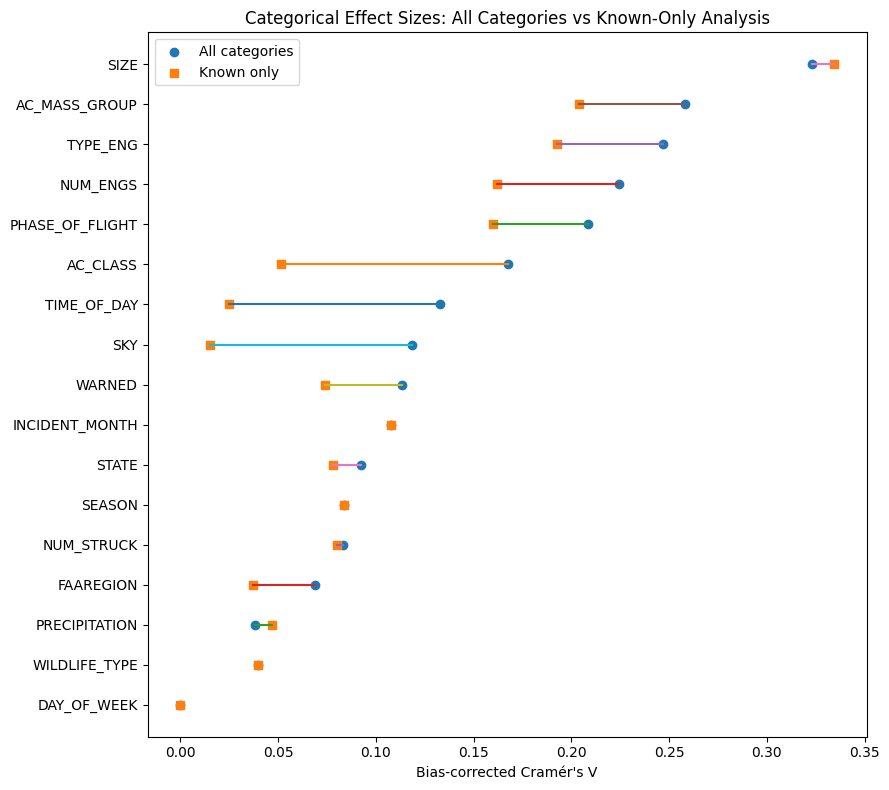

In [27]:
# Compare categorical effect sizes between all-category
# and known-only analyses.
effect_plot = (
    categorical_tests
    .pivot(
        index="Predictor",
        columns="Scope",
        values="Cramers_V_Bias_Corrected"
    )
    .reset_index()
)

# Retain predictors available in both analyses.
effect_plot = effect_plot.dropna(
    subset=["all_categories", "known_only"]
)

effect_plot["Maximum_Effect"] = effect_plot[
    ["all_categories", "known_only"]
].max(axis=1)

effect_plot = effect_plot.sort_values(
    "Maximum_Effect",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 8))

y_positions = np.arange(len(effect_plot))

ax.scatter(
    effect_plot["all_categories"],
    y_positions,
    marker="o",
    label="All categories"
)

ax.scatter(
    effect_plot["known_only"],
    y_positions,
    marker="s",
    label="Known only"
)

# Connect the two estimates for each predictor.
for y, all_value, known_value in zip(
    y_positions,
    effect_plot["all_categories"],
    effect_plot["known_only"]
):
    ax.plot(
        [all_value, known_value],
        [y, y]
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(effect_plot["Predictor"])

ax.set_xlabel("Bias-corrected Cramér's V")
ax.set_ylabel("")
ax.set_title(
    "Categorical Effect Sizes: All Categories vs Known-Only Analysis"
)

ax.legend()
plt.tight_layout()

save_figure(
    fig,
    "statistical_categorical_effect_size_comparison.png"
)

plt.show()

### Categorical association results

Wildlife size showed the strongest and most stable association with reported aircraft damage. Its bias-corrected Cramér’s V was 0.323 when all categories were included and 0.334 in the known-only analysis, indicating that the association was not driven by unavailable information.

Aircraft mass group, engine type, number of engines, and phase of flight also showed comparatively stronger associations. However, their effect sizes decreased after `Unknown` and `Not reported` categories were removed. This suggests that reporting availability contributed to part of the observed associations, although differences remained among the known categories.

Several variables showed notably smaller effect sizes in the known-only analysis, particularly time of day, sky condition, and aircraft class. For example, the effect size for sky condition decreased from 0.119 to 0.015, while aircraft class decreased from 0.168 to 0.051. Warning status and FAA region also became weaker after unavailable categories were excluded. These changes indicate that missing or unreported information was associated with the damage outcome and should be handled carefully during modelling.

Month and season had relatively small but consistent associations with damage. Day of week showed no evidence of association in either analysis after FDR adjustment. Although most other tests were statistically significant, their practical importance varied because of the large sample size.

Results for engine type, aircraft class, state, and precipitation should be interpreted cautiously because their contingency tables contained sparse expected cells. Precipitation was also unavailable in most records and had only a small known-only effect. Overall, wildlife size was the most robust categorical factor, while aircraft and flight characteristics provided additional but generally weaker associations.

In [28]:

def numeric_association_test(data, predictor):
    working = data[[predictor, "INDICATED_DAMAGE"]].copy()
    working[predictor] = pd.to_numeric(
        working[predictor], errors="coerce"
    )
    working = working.dropna(subset=[predictor, "INDICATED_DAMAGE"])

    no_damage = working.loc[
        working["INDICATED_DAMAGE"].eq(0), predictor
    ]
    damage = working.loc[
        working["INDICATED_DAMAGE"].eq(1), predictor
    ]

    if len(no_damage) == 0 or len(damage) == 0:
        return {
            "Predictor": predictor,
            "No_Damage_N": len(no_damage),
            "Damage_N": len(damage),
            "No_Damage_Median": np.nan,
            "Damage_Median": np.nan,
            "Median_Difference_Damage_Minus_No_Damage": np.nan,
            "Mann_Whitney_U": np.nan,
            "P_Value": np.nan,
            "Rank_Biserial_Correlation": np.nan,
        }

    test = mannwhitneyu(
        damage,
        no_damage,
        alternative="two-sided",
        method="asymptotic",
    )
    rank_biserial = (
        2 * test.statistic / (len(damage) * len(no_damage)) - 1
    )

    return {
        "Predictor": predictor,
        "No_Damage_N": len(no_damage),
        "Damage_N": len(damage),
        "No_Damage_Median": no_damage.median(),
        "Damage_Median": damage.median(),
        "Median_Difference_Damage_Minus_No_Damage": (
            damage.median() - no_damage.median()
        ),
        "Mann_Whitney_U": test.statistic,
        "P_Value": test.pvalue,
        "Rank_Biserial_Correlation": rank_biserial,
    }

numeric_results = [
    numeric_association_test(analysis_df, field)
    for field in numeric_fields
]
numeric_tests = pd.DataFrame(numeric_results)
numeric_tests["FDR_Adjusted_P_Value"] = benjamini_hochberg(
    numeric_tests["P_Value"]
)
numeric_tests["Absolute_Effect_Size"] = (
    numeric_tests["Rank_Biserial_Correlation"].abs()
)
numeric_tests = numeric_tests.sort_values(
    "Absolute_Effect_Size", ascending=False
).reset_index(drop=True)

save_table(
    numeric_tests,
    "numeric_damage_association_tests.csv",
    folder=STAT_DIR,
)
display(numeric_tests)


,Predictor,No_Damage_N,Damage_N,No_Damage_Median,Damage_Median,Median_Difference_Damage_Minus_No_Damage,Mann_Whitney_U,P_Value,Rank_Biserial_Correlation,FDR_Adjusted_P_Value,Absolute_Effect_Size
0,HEIGHT,145111,15806,25.0,400.0,375.0,1.388060e+09,0.000000e+00,0.210363,0.000000e+00,0.210363
1,DISTANCE,202314,9739,0.0,0.0,0.0,1.180199e+09,0.000000e+00,0.197967,0.000000e+00,0.197967
2,SPEED,89058,11728,140.0,135.0,-5.0,4.958638e+08,4.745940e-19,-0.050499,4.745940e-19,0.050499


### Numerical association results

Recorded height showed the strongest numerical association with reported aircraft damage. Damaging strikes had a median recorded height of 400 feet, compared with 25 feet for non-damaging strikes. The rank-biserial correlation was 0.210, indicating a meaningful but not strong tendency for damaging strikes to occur at higher recorded altitudes.

Distance also showed a positive association with damage, with a rank-biserial correlation of 0.198. Although the median was zero for both groups, damaging strikes tended to have larger non-zero distance values. The equal medians reflect the large concentration of observations at zero and do not imply that the two distributions were identical.

Recorded speed differed only slightly between the two groups. The median was 135 for damaging strikes and 140 for non-damaging strikes, with a small negative effect size of −0.050. Therefore, speed was statistically significant but had limited practical importance.

All three comparisons remained statistically significant after FDR adjustment. However, height and distance showed more practically relevant differences than speed. These results should still be interpreted cautiously because the variables had substantial missingness and skewed distributions.

In [29]:

# A single report-ready association index sorted by effect-size magnitude.
categorical_index = categorical_tests.loc[
    categorical_tests["Scope"].eq("known_only"),
    [
        "Predictor",
        "Scope",
        "Records",
        "P_Value",
        "FDR_Adjusted_P_Value",
        "Cramers_V_Bias_Corrected",
        "Assumption_Status",
    ],
].copy()
categorical_index["Test"] = "Chi-square"
categorical_index["Effect_Size_Metric"] = "Bias-corrected Cramer's V"
categorical_index["Effect_Size"] = categorical_index[
    "Cramers_V_Bias_Corrected"
]
categorical_index = categorical_index.drop(
    columns="Cramers_V_Bias_Corrected"
)

numeric_index = numeric_tests[
    [
        "Predictor",
        "P_Value",
        "FDR_Adjusted_P_Value",
        "Rank_Biserial_Correlation",
    ]
].copy()
numeric_index["Scope"] = "available_numeric_records"
numeric_index["Records"] = numeric_tests[
    ["No_Damage_N", "Damage_N"]
].sum(axis=1)
numeric_index["Test"] = "Mann–Whitney U"
numeric_index["Effect_Size_Metric"] = "Rank-biserial correlation"
numeric_index["Effect_Size"] = numeric_index[
    "Rank_Biserial_Correlation"
]
numeric_index["Assumption_Status"] = (
    "Nonparametric comparison; review missingness and extreme-value flags"
)
numeric_index = numeric_index.drop(
    columns="Rank_Biserial_Correlation"
)

association_index = pd.concat(
    [categorical_index, numeric_index],
    ignore_index=True,
    sort=False,
)
association_index["Absolute_Effect_Size"] = (
    association_index["Effect_Size"].abs()
)
association_index = association_index.sort_values(
    "Absolute_Effect_Size", ascending=False
).reset_index(drop=True)

save_table(
    association_index,
    "rq1_association_effect_size_index.csv",
    folder=STAT_DIR,
)
display(association_index)


,Predictor,Scope,Records,P_Value,FDR_Adjusted_P_Value,Assumption_Status,Test,Effect_Size_Metric,Effect_Size,Absolute_Effect_Size
0,SIZE,known_only,287615,0.000000e+00,0.000000e+00,Acceptable,Chi-square,Bias-corrected Cramer's V,0.334245,0.334245
1,HEIGHT,available_numeric_records,160917,0.000000e+00,0.000000e+00,Nonparametric comparison; review missingness a...,Mann–Whitney U,Rank-biserial correlation,0.210363,0.210363
2,AC_MASS_GROUP,known_only,228162,0.000000e+00,0.000000e+00,Acceptable,Chi-square,Bias-corrected Cramer's V,0.204036,0.204036
3,DISTANCE,available_numeric_records,212053,0.000000e+00,0.000000e+00,Nonparametric comparison; review missingness a...,Mann–Whitney U,Rank-biserial correlation,0.197967,0.197967
4,TYPE_ENG,known_only,227849,0.000000e+00,0.000000e+00,Review sparse expected cells,Chi-square,Bias-corrected Cramer's V,0.192883,0.192883
5,NUM_ENGS,known_only,227893,0.000000e+00,0.000000e+00,Acceptable,Chi-square,Bias-corrected Cramer's V,0.162165,0.162165
6,PHASE_OF_FLIGHT,known_only,194586,0.000000e+00,0.000000e+00,Acceptable,Chi-square,Bias-corrected Cramer's V,0.159825,0.159825
7,INCIDENT_MONTH,known_only,319107,0.000000e+00,0.000000e+00,Acceptable,Chi-square,Bias-corrected Cramer's V,0.107921,0.107921
8,SEASON,known_only,319107,0.000000e+00,0.000000e+00,Acceptable,Chi-square,Bias-corrected Cramer's V,0.083909,0.083909
9,NUM_STRUCK,known_only,318426,0.000000e+00,0.000000e+00,Acceptable,Chi-square,Bias-corrected Cramer's V,0.080236,0.080236


### Overall statistical summary

Wildlife size showed the strongest and most stable categorical association with reported aircraft damage. Aircraft mass group, engine type, number of engines, and phase of flight also showed comparatively notable associations. Among the numerical variables, recorded height and distance had more meaningful distributional differences, while speed showed only a small effect.

Month, season, number struck, state, and warning status had weaker associations, while day of week showed no evidence of association. Results for engine type, aircraft class, state, and precipitation require caution because of sparse expected cells, and several numerical and environmental variables had substantial unavailable information.

Because of the large sample size, predictor importance should be assessed using effect sizes, confidence intervals, data availability, and consistency across sensitivity analyses rather than statistical significance alone. The combined effect-size ranking provides a broad descriptive comparison because categorical and numerical variables use different effect-size measures.

## 12. Reporting and interpretation guidelines

The following guidelines are applied when interpreting and reporting the results:

- Report record counts together with damage rates.
- Use Wilson confidence intervals when comparing categories with different sample sizes.
- Treat `Unknown` and `Not reported` as reporting states rather than substantive exposure levels.
- Use the known-only sensitivity analysis as the main substantive association check, while using the all-category analysis to examine reporting-related patterns.
- Prioritize effect sizes, consistency, confidence intervals, and data availability rather than statistical significance alone.
- Do not infer causal relationships from descriptive damage rates, chi-square tests, Mann–Whitney U tests, or model-explainability results.
- Do not interpret airport record counts as strike probabilities because the dataset does not contain aircraft-movement denominators.
- Do not use post-event outcomes, including `DAMAGE_LEVEL`, component-damage fields, operational consequences, injuries, fatalities, or costs, as predictors of `INDICATED_DAMAGE`.


## 13. Proposal coverage matrix and final output manifest


In [30]:
# ============================================================
# FINAL RQ1 COVERAGE, OUTPUT MANIFEST, AND CHECKPOINT
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# 1. Confirm the final output folders
# ------------------------------------------------------------

FINAL_TABLE_DIR = OUTPUT_DIR / "tables"
FINAL_FIGURE_DIR = OUTPUT_DIR / "figures"
FINAL_STAT_DIR = OUTPUT_DIR / "statistical_tests"

FINAL_TABLE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_STAT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Create the RQ1 proposal coverage matrix
# ------------------------------------------------------------

proposal_coverage = pd.DataFrame([
    {
        "RQ1_Domain": "Temporal",
        "Variables": (
            "INCIDENT_YEAR, INCIDENT_MONTH, SEASON, "
            "DAY_OF_WEEK, TIME_OF_DAY"
        ),
        "Descriptive_Output": (
            "Counts, damage rates, 95% CIs, and figures"
        ),
        "Statistical_Output": (
            "Chi-square tests and Cramer's V "
            "for categorical variables"
        ),
    },
    {
        "RQ1_Domain": "Geographic",
        "Variables": (
            "FAAREGION, STATE, AIRPORT_ID"
        ),
        "Descriptive_Output": (
            "Region, state, and airport counts "
            "and damage rates"
        ),
        "Statistical_Output": (
            "Region and state chi-square tests "
            "and Cramer's V; airports descriptive only"
        ),
    },
    {
        "RQ1_Domain": "Wildlife",
        "Variables": (
            "WILDLIFE_TYPE, SIZE, NUM_STRUCK, SPECIES"
        ),
        "Descriptive_Output": (
            "Counts, damage rates, 95% CIs, "
            "top-species results, and wildlife-by-season outputs"
        ),
        "Statistical_Output": (
            "Wildlife type, size, and number-struck tests; "
            "exact species descriptive only"
        ),
    },
    {
        "RQ1_Domain": "Aircraft",
        "Variables": (
            "AC_CLASS, AC_MASS_GROUP, TYPE_ENG, NUM_ENGS"
        ),
        "Descriptive_Output": (
            "Counts, damage rates, 95% CIs, figures, "
            "and wildlife-size-by-aircraft-mass outputs"
        ),
        "Statistical_Output": (
            "Chi-square tests and Cramer's V"
        ),
    },
    {
        "RQ1_Domain": "Flight",
        "Variables": (
            "PHASE_OF_FLIGHT, WARNED, HEIGHT, SPEED, DISTANCE"
        ),
        "Descriptive_Output": (
            "Categorical damage rates, numerical summaries, "
            "figures, and wildlife-size-by-flight-phase outputs"
        ),
        "Statistical_Output": (
            "Chi-square tests, Cramer's V, Mann–Whitney U tests, "
            "and rank-biserial correlations"
        ),
    },
    {
        "RQ1_Domain": "Environmental context",
        "Variables": (
            "SKY, PRECIPITATION"
        ),
        "Descriptive_Output": (
            "Counts, damage rates, and data availability"
        ),
        "Statistical_Output": (
            "Known-only sensitivity tests with "
            "strong missingness limitations"
        ),
    },
])

proposal_coverage_path = (
    FINAL_TABLE_DIR / "proposal_rq1_coverage_matrix.csv"
)

proposal_coverage.to_csv(
    proposal_coverage_path,
    index=False,
)

display(proposal_coverage)


# ------------------------------------------------------------
# 3. Helper functions for rebuilding the output manifest
# ------------------------------------------------------------

def safe_relative_path(path, root):
    """
    Return a project-relative path when possible.
    Otherwise, return the complete file path.
    """
    try:
        return str(path.relative_to(root))
    except ValueError:
        return str(path)


def inspect_csv_file(path):
    """
    Read an exported CSV and return its row and column counts.
    A failed read is recorded as unavailable rather than
    stopping the notebook.
    """
    try:
        table = pd.read_csv(path)
        return int(table.shape[0]), int(table.shape[1])
    except Exception as error:
        print(
            f"Warning: could not inspect {path.name}: {error}"
        )
        return pd.NA, pd.NA


# ------------------------------------------------------------
# 4. Rebuild the manifest from actual exported files
# ------------------------------------------------------------

manifest_rows = []

# The manifest and checkpoint are excluded because they describe
# the outputs rather than being analytical outputs themselves.
excluded_filenames = {
    "output_manifest.csv",
    "notebook03_checkpoint.csv",
}

# Add all CSV tables from the output directory.
for file_path in sorted(OUTPUT_DIR.rglob("*.csv")):
    if file_path.name in excluded_filenames:
        continue

    rows, columns = inspect_csv_file(file_path)

    manifest_rows.append({
        "artifact_type": "table",
        "filename": file_path.name,
        "relative_path": safe_relative_path(
            file_path,
            ROOT,
        ),
        "rows": rows,
        "columns": columns,
    })


# Add all exported figures.
figure_extensions = {
    ".png",
    ".jpg",
    ".jpeg",
    ".svg",
    ".pdf",
}

for file_path in sorted(OUTPUT_DIR.rglob("*")):
    if (
        file_path.is_file()
        and file_path.suffix.lower() in figure_extensions
    ):
        manifest_rows.append({
            "artifact_type": "figure",
            "filename": file_path.name,
            "relative_path": safe_relative_path(
                file_path,
                ROOT,
            ),
            "rows": pd.NA,
            "columns": pd.NA,
        })


# Create and clean the final manifest.
manifest = pd.DataFrame(
    manifest_rows,
    columns=[
        "artifact_type",
        "filename",
        "relative_path",
        "rows",
        "columns",
    ],
)

if not manifest.empty:
    manifest = (
        manifest
        .drop_duplicates(
            subset=[
                "artifact_type",
                "relative_path",
            ],
            keep="last",
        )
        .sort_values(
            by=[
                "artifact_type",
                "relative_path",
            ],
        )
        .reset_index(drop=True)
    )


# Export the final manifest.
manifest_path = OUTPUT_DIR / "output_manifest.csv"

manifest.to_csv(
    manifest_path,
    index=False,
)


# ------------------------------------------------------------
# 5. Count descriptive and statistical outputs separately
# ------------------------------------------------------------

descriptive_table_count = len(
    [
        path
        for path in FINAL_TABLE_DIR.rglob("*.csv")
        if path.name not in excluded_filenames
    ]
)

figure_count = len(
    [
        path
        for path in FINAL_FIGURE_DIR.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower() in figure_extensions
        )
    ]
)

statistical_table_count = len(
    [
        path
        for path in FINAL_STAT_DIR.rglob("*.csv")
        if path.name not in excluded_filenames
    ]
)


# ------------------------------------------------------------
# 6. Create the final notebook checkpoint
# ------------------------------------------------------------

analytical_year_min = int(
    analysis_df["INCIDENT_YEAR"].min()
)

analytical_year_max = int(
    analysis_df["INCIDENT_YEAR"].max()
)

checkpoint = pd.DataFrame(
    [
        {
            "Checkpoint": "Canonical input",
            "Result": safe_relative_path(
                INPUT_FILE,
                ROOT,
            ),
        },
        {
            "Checkpoint": "Analytical years",
            "Result": (
                f"{analytical_year_min}–"
                f"{analytical_year_max}"
            ),
        },
        {
            "Checkpoint": "Analytical records",
            "Result": int(len(analysis_df)),
        },
        {
            "Checkpoint": "Primary target",
            "Result": "INDICATED_DAMAGE",
        },
        {
            "Checkpoint": "Descriptive tables",
            "Result": descriptive_table_count,
        },
        {
            "Checkpoint": "Figures",
            "Result": figure_count,
        },
        {
            "Checkpoint": "Statistical output tables",
            "Result": statistical_table_count,
        },
        {
            "Checkpoint": "Categorical tests",
            "Result": int(len(categorical_tests)),
        },
        {
            "Checkpoint": "Numeric tests",
            "Result": int(len(numeric_tests)),
        },
        {
            "Checkpoint": "Causal claims permitted",
            "Result": "No",
        },
        {
            "Checkpoint": (
                "Ordinary-flight strike probability estimable"
            ),
            "Result": "No",
        },
    ],
    columns=[
        "Checkpoint",
        "Result",
    ],
)


# Export the checkpoint.
checkpoint_path = (
    OUTPUT_DIR / "notebook03_checkpoint.csv"
)

checkpoint.to_csv(
    checkpoint_path,
    index=False,
)


# ------------------------------------------------------------
# 7. Final validation messages
# ------------------------------------------------------------

print("=" * 65)
print("NOTEBOOK 03 FINAL OUTPUT CHECK")
print("=" * 65)

print(
    f"Canonical dataset: "
    f"{safe_relative_path(INPUT_FILE, ROOT)}"
)

print(
    f"Analytical period: "
    f"{analytical_year_min}–{analytical_year_max}"
)

print(
    f"Analytical records: "
    f"{len(analysis_df):,}"
)

print(
    f"Descriptive tables: "
    f"{descriptive_table_count}"
)

print(
    f"Figures: "
    f"{figure_count}"
)

print(
    f"Statistical output tables: "
    f"{statistical_table_count}"
)

print(
    f"Categorical tests: "
    f"{len(categorical_tests)}"
)

print(
    f"Numeric tests: "
    f"{len(numeric_tests)}"
)

print(
    f"Manifest entries: "
    f"{len(manifest)}"
)

print("-" * 65)
print("Output manifest:", manifest_path)
print("Checkpoint:", checkpoint_path)
print("RQ1 coverage matrix:", proposal_coverage_path)
print("=" * 65)


# Display the final outputs.
display(checkpoint)
display(manifest)

,RQ1_Domain,Variables,Descriptive_Output,Statistical_Output
0,Temporal,"INCIDENT_YEAR, INCIDENT_MONTH, SEASON, DAY_OF_...","Counts, damage rates, 95% CIs, and figures",Chi-square tests and Cramer's V for categorica...
1,Geographic,"FAAREGION, STATE, AIRPORT_ID","Region, state, and airport counts and damage r...",Region and state chi-square tests and Cramer's...
2,Wildlife,"WILDLIFE_TYPE, SIZE, NUM_STRUCK, SPECIES","Counts, damage rates, 95% CIs, top-species res...","Wildlife type, size, and number-struck tests; ..."
3,Aircraft,"AC_CLASS, AC_MASS_GROUP, TYPE_ENG, NUM_ENGS","Counts, damage rates, 95% CIs, figures, and wi...",Chi-square tests and Cramer's V
4,Flight,"PHASE_OF_FLIGHT, WARNED, HEIGHT, SPEED, DISTANCE","Categorical damage rates, numerical summaries,...","Chi-square tests, Cramer's V, Mann–Whitney U t..."
5,Environmental context,"SKY, PRECIPITATION","Counts, damage rates, and data availability",Known-only sensitivity tests with strong missi...


NOTEBOOK 03 FINAL OUTPUT CHECK
Canonical dataset: data\processed\faa_strikes_analytical.csv
Analytical period: 1990–2024
Analytical records: 319,107
Descriptive tables: 38
Figures: 45
Statistical output tables: 3
Categorical tests: 34
Numeric tests: 3
Manifest entries: 86
-----------------------------------------------------------------
Output manifest: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\faa-wildlife-strike-damage-analysis\outputs\03_descriptive_and_diagnostic\output_manifest.csv
Checkpoint: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\faa-wildlife-strike-damage-analysis\outputs\03_descriptive_and_diagnostic\notebook03_checkpoint.csv
RQ1 coverage matrix: d:\STUDY\UNF\MDA\term5_capstone_project\assignment\project2\faa-wildlife-strike-damage-analysis\outputs\03_descriptive_and_diagnostic\tables\proposal_rq1_coverage_matrix.csv


,Checkpoint,Result
0,Canonical input,data\processed\faa_strikes_analytical.csv
1,Analytical years,1990–2024
2,Analytical records,319107
3,Primary target,INDICATED_DAMAGE
4,Descriptive tables,38
5,Figures,45
6,Statistical output tables,3
7,Categorical tests,34
8,Numeric tests,3
9,Causal claims permitted,No


,artifact_type,filename,relative_path,rows,columns
0,figure,01_damage_distribution.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>
1,figure,aircraft_aircraft_class_counts.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>
2,figure,aircraft_aircraft_class_damage_rate.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>
3,figure,aircraft_aircraft_mass_group_counts.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>
4,figure,aircraft_aircraft_mass_group_damage_rate.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>
5,figure,aircraft_engine_type_counts.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>
6,figure,aircraft_engine_type_damage_rate.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>
7,figure,aircraft_number_of_engines_counts.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>
8,figure,aircraft_number_of_engines_damage_rate.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>
9,figure,consequence_damage_severity_among_damaged.png,outputs\03_descriptive_and_diagnostic\figures\...,<NA>,<NA>


### RQ1 coverage and final output checkpoint

The completed analysis covers all six domains defined for RQ1: temporal, geographic, wildlife, aircraft, flight, and environmental context. The outputs include record counts, damage rates, Wilson confidence intervals, numerical summaries, cross-factor comparisons, data-quality diagnostics, and statistical association tests.

The final checkpoint confirms that the analysis used the canonical Notebook 02 dataset, covering 319,107 reported wildlife strikes from 1990 to 2024. The notebook generated 38 descriptive tables, 45 figures, and three statistical output tables. The output manifest contains 86 unique artifacts and provides a reproducible record of the files created by the analysis.

The results describe associations among reported wildlife strikes and do not support causal conclusions or estimates of ordinary-flight strike probability.

## 14. Hand-off to reporting and modelling

After this notebook has been successfully run from a fresh kernel:

- use the exported descriptive tables and figures in the final report and presentation;
- use `rq1_association_effect_size_index.csv` to identify the associations with the greatest practical importance;
- review the statistical assumption diagnostics before deciding which test results are suitable for reporting;
- pass the canonical dataset produced by Notebook 02 directly to the binary damage-modelling notebook, without creating another independently cleaned version;
- keep the external 2025 validation year and partial 2026 records outside the descriptive analytical population, in accordance with the locked validation design.